# EDA IMG 01 — Raw images exploration

This notebook performs an initial exploratory analysis of the raw metadata files used in the project.

The objective is to inspect the structure, dimensions, columns, missing values and basic content of the three original CSV files stored in `data/raw/metadata`.

No preprocessing or feature engineering is performed in this notebook. The goal is only to understand the raw input data before defining the preprocessing pipeline.


This notebook aims to answer the following questions:

1. How many image files exist physically?
2. Do image files match metadata records?
3. Are there missing images?
4. Are there corrupted images?
5. What image formats are present?
6. What image resolutions exist?
7. What is the width and height distribution?
8. What disk space does the dataset occupy?
9. What resize strategy should be adopted?
10. Are there potential issues that could affect model training?

The results obtained in this notebook will guide all subsequent preprocessing and deep learning decisions.

# Data Loading

In [83]:
# import standard libraries

import pandas as pd

from io import BytesIO
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

# Project utilities
from skin_lesion_ai.utils.data_utils import load_yaml_config, path, load_raw_metadata

from skin_lesion_ai.visualisation.eda_plots import (
    set_eda_style,
    clean_axis_labels,
    EDA_STYLE,
    STATISTIC_PALETTE,
)

# Set the EDA style
set_eda_style()
figures = {}

## Load Metadata

In [6]:
# Load raw metadata

df1, df2, df3 = load_raw_metadata()

print("df1 - ground_truth:", df1.shape)
print("df2 - supplement:", df2.shape)
print("df3 - metadata:", df3.shape)

/Users/carlesraichbros/my-image-classifier/src/skin_lesion_ai/utils/data_utils.py:44: DtypeWarning: Columns (0: iddx_5) have mixed types. Specify dtype option on import or set low_memory=False.
  supplement = pd.read_csv(path(raw["supplement_csv"]))


df1 - ground_truth: (401059, 2)
df2 - supplement: (401059, 13)
df3 - metadata: (401059, 42)


## Image Directory Configuration

In [3]:
# Set path to images

config = load_yaml_config(path("configs/data_config.yaml"))
IMAGE_DIR = path(config["paths"]["raw"]["images"])

# Dataset Integrity Audit

## Physical Image Count

Count all image files available in the dataset directory.

In [4]:
# List all image files in the directory

image_files = sorted(list(IMAGE_DIR.glob("*.jpg")))

print(len(image_files))

401059


## Metadata vs Physical Files Validation

In [7]:
# Check for duplicates in metadata and images

metadata_ids = set(df1["isic_id"])

image_ids = {img.stem for img in image_files}

print("Metadata:", len(metadata_ids))
print("Images:", len(image_ids))

Metadata: 401059
Images: 401059


In [8]:
# Find missing images in the metadata

missing_images = metadata_ids - image_ids

len(missing_images)

0

In [9]:
# Find extra images not in metadata

extra_images = image_ids - metadata_ids

len(extra_images)

0

The metadata repository and the physical image repository contain exactly the same number of observations.

No missing or orphan image files were detected, confirming complete consistency between metadata and image storage.

## File Extensions Audit

In [10]:
# Check file extensions of images

extensions = {}

for file in image_files:
    ext = file.suffix.lower()
    extensions[ext] = extensions.get(ext, 0) + 1

pd.Series(extensions)

.jpg    401059
dtype: int64

There are no multiple image formats or extensions, only .jpg.

# Image Quality Audit

## Image Color Mode Audit

Deep learning models expect a fixed number of input channels.

Therefore, it is important to verify whether all images share the same color representation format.

Datasets containing a mixture of RGB, RGBA, grayscale or other color modes would require additional preprocessing to standardize the number of channels before model training.

This section evaluates the distribution of image color modes across the complete dataset.

In [11]:
# Analyze image modes (color formats)

image_modes = {}

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            mode = img.mode

            image_modes[mode] = image_modes.get(mode, 0) + 1

    except Exception:
        pass

mode_df = pd.Series(image_modes).sort_values(ascending=False).rename("count")

mode_df

  0%|          | 0/401059 [00:00<?, ?it/s]

RGB    401059
Name: count, dtype: int64

In [12]:
# percentages of each mode

mode_pct = mode_df / mode_df.sum() * 100

mode_pct.round(4)

RGB    100.0
Name: count, dtype: float64

All images were stored using the RGB color mode.

This guarantees a homogeneous three-channel representation across the entire dataset and eliminates the need for channel standardization during preprocessing.

## Corrupted Images Audit

In [13]:
# Check for corrupted images

corrupted_files = []

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        corrupted_files.append(img_path.name)

  0%|          | 0/401059 [00:00<?, ?it/s]

In [14]:
# Count corrupted images

len(corrupted_files)

0

No corrupted image files were identified.

Consequently, no image-repair or image-removal procedures are required prior to preprocessing.

# Image Resolution Audit

In [15]:
# Analyze image resolutions

image_stats = []
failed_images = []

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            width, height = img.size

            image_stats.append(
                {
                    "image_id": img_path.stem,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                }
            )

    except Exception as e:
        failed_images.append(
            {
                "image_id": img_path.stem,
                "image_path": str(img_path),
                "error": str(e),
            }
        )

resolution_df = pd.DataFrame(image_stats)

failed_df = pd.DataFrame(failed_images)

print("Processed images:", len(resolution_df))
print("Failed images:", len(failed_df))

  0%|          | 0/401059 [00:00<?, ?it/s]

Processed images: 401059
Failed images: 0


## Resolution Statistics

In [19]:
# Describe the resolution statistics


def descriptive_summary(series, suffix=""):
    values = series.dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    return {
        "n": values.size,
        "missing": series.isna().sum(),
        "n_unique": values.nunique(),
        f"mean{suffix}": values.mean(),
        f"std{suffix}": values.std(),
        f"min{suffix}": values.min(),
        f"q1{suffix}": q1,
        f"median{suffix}": values.median(),
        f"q3{suffix}": q3,
        f"max{suffix}": values.max(),
        f"iqr{suffix}": iqr,
        "skewness": values.skew(),
        "kurtosis": values.kurt(),
    }


resolution_descriptive_summary = pd.DataFrame(
    {
        "width": descriptive_summary(resolution_df["width"], suffix=""),
        "height": descriptive_summary(resolution_df["height"], suffix=""),
        "aspect_ratio": descriptive_summary(resolution_df["aspect_ratio"], suffix=""),
    }
).T

print(resolution_descriptive_summary.round(3))

                     n  missing  n_unique     mean     std   min     q1  \
width         401059.0      0.0     111.0  133.245  18.271  41.0  121.0   
height        401059.0      0.0     111.0  133.245  18.271  41.0  121.0   
aspect_ratio  401059.0      0.0       1.0    1.000   0.000   1.0    1.0   

              median     q3    max   iqr  skewness  kurtosis  
width          131.0  143.0  269.0  22.0     0.743     2.053  
height         131.0  143.0  269.0  22.0     0.743     2.053  
aspect_ratio     1.0    1.0    1.0   0.0     0.000     0.000  


All 401,059 images were successfully processed, with no missing values in the resolution metadata. 

Width and height showed identical descriptive values, while the constant aspect ratio of 1.0 confirmed that all images were square. 

The median image size was 131 × 131 pixels (IQR: 121–143), with a mean resolution of 133.2 ± 18.3 pixels. Image dimensions ranged from 41 × 41 to 269 × 269 pixels, indicating moderate variability in image size across the dataset. 

The positive skewness value (0.743) suggests a slight right-skewed distribution, driven by a small number of larger images. The positive kurtosis value (2.053) also indicates a more peaked distribution with somewhat heavier tails than a normal distribution, suggesting the presence of some extreme resolution values. 

Overall, however, image sizes were relatively homogeneous, with most images concentrated around 120–145 pixels.


In [20]:
# Describe the failed images

if not failed_df.empty:
    failed_df.describe()

failed_df.head()

""


No images failed during resolution extraction, indicating that all image files could be opened successfully by PIL.

## Resolution Distribution

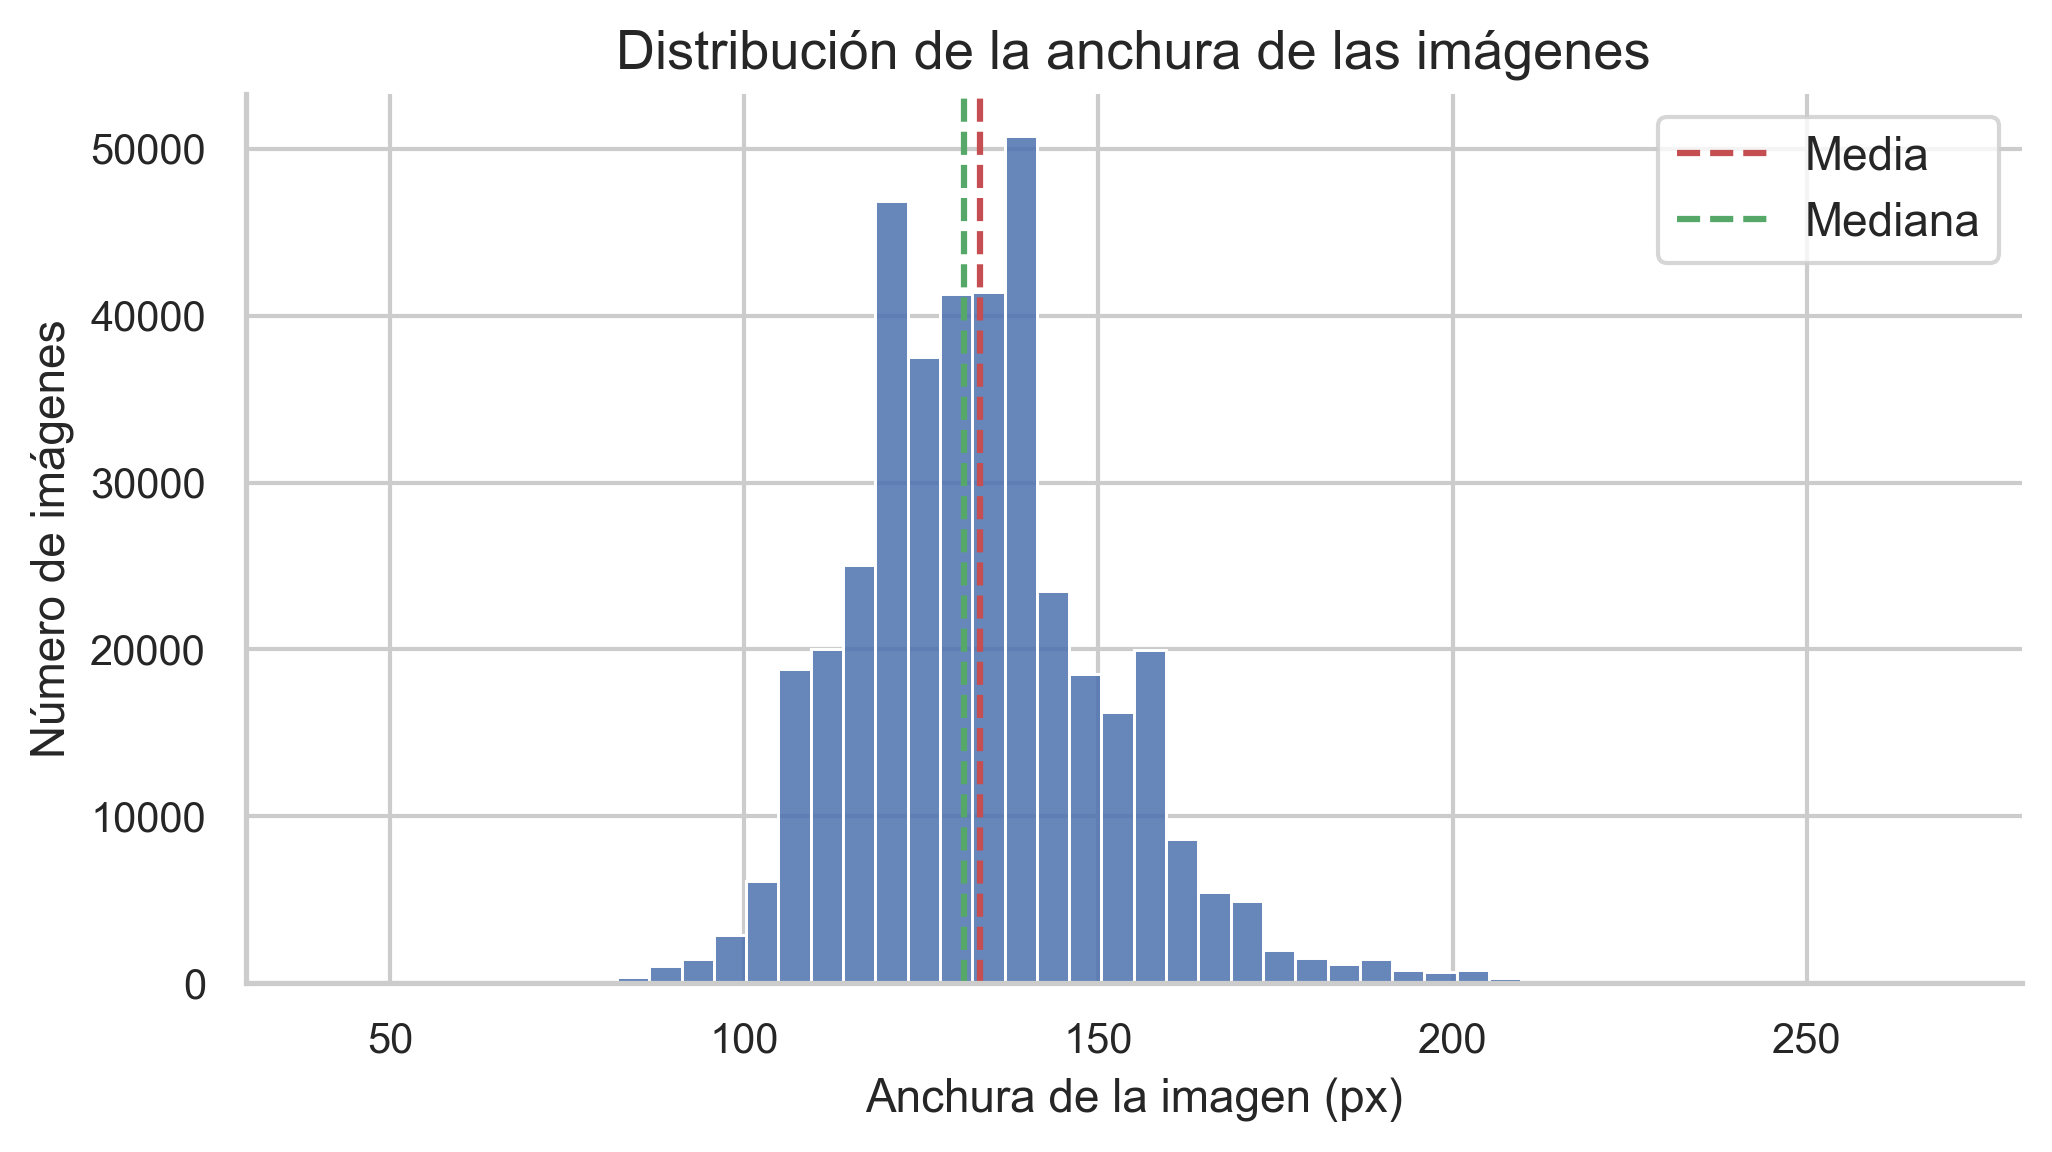

In [84]:
# Plot histograms of width and height

# Plot image width distribution

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.histplot(
    data=resolution_df,
    x="width",
    bins=50,
    kde=False,
    color=STATISTIC_PALETTE["distribution"],
    alpha=EDA_STYLE["bar_alpha"],
    ax=ax,
)

ax.axvline(
    resolution_df["width"].mean(),
    color=STATISTIC_PALETTE["mean"],
    linestyle="--",
    linewidth=1.5,
    label="Media",
)

ax.axvline(
    resolution_df["width"].median(),
    color=STATISTIC_PALETTE["median"],
    linestyle="--",
    linewidth=1.5,
    label="Mediana",
)

clean_axis_labels(
    ax,
    xlabel="Anchura de la imagen (px)",
    ylabel="Número de imágenes",
    title="Distribución de la anchura de las imágenes",
)

ax.legend()

plt.tight_layout()
plt.show()

figures["image_resolution_distribution"] = fig

The histogram shows one main concentration of image widths around 120–145 pixels. The distribution is mildly right-skewed, with a small subset of higher-resolution images extending the right tail up to 269 pixels.

## Resolution-Based Candidate Analysis

The objective of this section is to identify images with unusually low or high native resolution that may affect downstream preprocessing decisions.

Since all images are square, image width is used as a proxy for native image resolution.

The analysis focuses primarily on low-resolution images, as these may require stronger upsampling when resized to the model input size. High-resolution images are also described for completeness, but they are less concerning because resizing would mainly involve downsampling.

The IQR rule was not used as the main decision criterion because image resolution has a bounded and discrete distribution, and the practical preprocessing concern is related to resizing impact rather than statistical distance from the median.

No automatic exclusion is applied at this stage. Instead, candidate images are flagged for visual inspection and for subsequent assessment of their distribution across diagnostic groups, sources and patients.

In [33]:
# Percentile-based resolution thresholds

resolution_var = "width"

percentile_thresholds = [0.01, 0.05, 0.95, 0.99]

percentile_summary = []

for percentile in percentile_thresholds:
    threshold_value = resolution_df[resolution_var].quantile(percentile)

    if percentile < 0.5:
        n_images = (resolution_df[resolution_var] <= threshold_value).sum()
        tail = "lower"
        criterion = f"<= {threshold_value:.0f} px"
    else:
        n_images = (resolution_df[resolution_var] >= threshold_value).sum()
        tail = "upper"
        criterion = f">= {threshold_value:.0f} px"

    percentage = n_images / len(resolution_df) * 100

    percentile_summary.append(
        {
            "tail": tail,
            "percentile": percentile,
            "threshold_px": threshold_value,
            "criterion": criterion,
            "n_images": n_images,
            "percentage": percentage,
        }
    )

percentile_summary_df = pd.DataFrame(percentile_summary)

print(percentile_summary_df.round(3))

    tail  percentile  threshold_px  criterion  n_images  percentage
0  lower        0.01          97.0   <= 97 px      4695       1.171
1  lower        0.05         107.0  <= 107 px     23579       5.879
2  upper        0.95         163.0  >= 163 px     23869       5.951
3  upper        0.99         189.0  >= 189 px      4438       1.107


The 1st percentile identified images with native resolution ≤97 px, corresponding to 4,695 images (1.17% of the dataset). The 5th percentile identified images with native resolution ≤107 px, corresponding to 23,579 images (5.88%).

These lower-tail groups are considered low-resolution candidates for further inspection, particularly because they would require upsampling if resized to a larger model input size.

Upper-tail thresholds were also inspected for completeness. Images at or above the 95th percentile had native resolution ≥163 px, representing 23,869 images (5.95%), while images at or above the 99th percentile had native resolution ≥189 px, representing 4,438 images (1.11%).

High-resolution images are less concerning from a preprocessing perspective because resizing would involve downsampling rather than upsampling. Therefore, upper-tail observations are described but are not considered exclusion candidates based on resolution alone.

In [34]:
# Extract low-resolution candidate lesion IDs

p1_threshold = resolution_df["width"].quantile(0.01)
p5_threshold = resolution_df["width"].quantile(0.05)

low_resolution_p1 = (
    resolution_df.loc[resolution_df["width"] <= p1_threshold]
    .copy()
    .rename(columns={"image_id": "lesion_id"})
    .sort_values("width")
)

low_resolution_p5 = (
    resolution_df.loc[resolution_df["width"] <= p5_threshold]
    .copy()
    .rename(columns={"image_id": "lesion_id"})
    .sort_values("width")
)

low_resolution_p1.head(20)

,lesion_id,width,height,aspect_ratio
7543,ISIC_0259506,41,41,1.0
379346,ISIC_9458405,45,45,1.0
77129,ISIC_1981556,45,45,1.0
271835,ISIC_6808109,47,47,1.0
96012,ISIC_2450218,47,47,1.0
212890,ISIC_5352050,49,49,1.0
246595,ISIC_6196043,49,49,1.0
257409,ISIC_6460824,49,49,1.0
306354,ISIC_7661380,49,49,1.0
278433,ISIC_6973695,51,51,1.0


The corresponding lesion identifiers were extracted from the image filenames. This makes the analysis actionable, as these images can be visually inspected and later cross-checked against diagnostic group, data source and patient-level metadata.

The 1st percentile group is the most relevant set for manual inspection, whereas the 5th percentile group provides a broader low-resolution candidate set for sensitivity analyses.

In [35]:
# Threshold analysis for low-resolution images

candidate_thresholds = [50, 60, 70, 80, 90, 96, 100, 107, 120, 128]

threshold_summary = []

for threshold in candidate_thresholds:
    n_images = (resolution_df["width"] < threshold).sum()
    percentage = n_images / len(resolution_df) * 100

    threshold_summary.append(
        {
            "threshold_px": threshold,
            "n_images_below_threshold": n_images,
            "percentage_below_threshold": percentage,
        }
    )

threshold_summary_df = pd.DataFrame(threshold_summary)

print(threshold_summary_df.round(3))

   threshold_px  n_images_below_threshold  percentage_below_threshold
0            50                         9                       0.002
1            60                        50                       0.012
2            70                       191                       0.048
3            80                       572                       0.143
4            90                      1671                       0.417
5            96                      3547                       0.884
6           100                      6416                       1.600
7           107                     17318                       4.318
8           120                     90696                      22.614
9           128                    160794                      40.092


Several absolute resolution thresholds were evaluated to quantify how many images would fall below different native image sizes.

Very low thresholds identified only a small fraction of the dataset: 572 images (0.14%) were below 80 px, 1,671 images (0.42%) below 90 px, and 6,416 images (1.60%) below 100 px. These images represent the most relevant low-resolution candidates for visual inspection.

However, the number of affected images increased markedly at higher thresholds. Images below 107 px represented 4.32% of the dataset, while images below 120 px represented 22.61%. Finally, 160,794 images (40.09%) were below 128 px.

Therefore, thresholds close to 120–128 px should not be interpreted as exclusion criteria. Instead, they indicate the proportion of images that would require some degree of upsampling if resized to 128 × 128 pixels. In contrast, lower thresholds such as 80, 90 or 100 px are more useful for identifying potentially problematic low-resolution images.

# Resize Strategy and Visual Inspection Analysis

The objective of this section is to evaluate potential image resizing strategies for model development.

Since all images are square but have different native resolutions, resizing will be required before model training. The key question is not only which target input size is technically feasible, but also how much interpolation each candidate size would introduce, especially for low-resolution images.

This analysis combines visual inspection and quantitative resizing metrics. The goal is to identify reasonable candidate input sizes, quantify the proportion of images that would require upsampling or downsampling, and assess whether any subset of images should be flagged for visual inspection or potential sensitivity analyses.

No image is excluded automatically at this stage. Resolution-based exclusion would only be considered if a subset of images required extreme upsampling and showed poor visual quality or systematic differences across diagnostic groups, sources or patients.

### Candidate Input Sizes

Several candidate input sizes were evaluated to cover different preprocessing scenarios:

- 96 × 96: lightweight option below the central native resolution of the dataset.
- 128 × 128: size close to the median native resolution.
- 160 × 160: intermediate option that may preserve more spatial detail.
- 192 × 192: higher-resolution option with increased computational cost.
- 224 × 224: common input size for many pretrained computer vision models.

These candidates are not selected solely based on image resolution. They will later be compared with storage and computational considerations.

In [39]:
# Define candidate input sizes for resizing

candidate_sizes = [96, 128, 160, 192, 224]

candidate_size_df = pd.DataFrame(
    {
        "candidate_size_px": candidate_sizes,
        "input_shape": [f"{size} × {size}" for size in candidate_sizes],
    }
)

candidate_size_df

,candidate_size_px,input_shape
0,96,96 × 96
1,128,128 × 128
2,160,160 × 160
3,192,192 × 192
4,224,224 × 224


### Visual Inspection of Representative Native Resolutions

Representative images were selected from different points of the native resolution distribution: minimum, 1st percentile, 5th percentile, median, 95th percentile and maximum.

This allows visual inspection of both low-resolution and high-resolution examples before resizing. The aim is to assess whether the lowest-resolution images appear visually degraded or whether they still preserve enough information to justify retaining them.

In [42]:
# Map image IDs to image paths
image_path_map = {img_path.stem: img_path for img_path in IMAGE_DIR.glob("*.jpg")}

# Select representative images based on native resolution

representative_specs = {
    "Mínimo": resolution_df["width"].min(),
    "P1": resolution_df["width"].quantile(0.01),
    "P5": resolution_df["width"].quantile(0.05),
    "Mediana": resolution_df["width"].median(),
    "P95": resolution_df["width"].quantile(0.95),
    "Máximo": resolution_df["width"].max(),
}

representative_images = []

for label, target_width in representative_specs.items():
    idx = (resolution_df["width"] - target_width).abs().idxmin()
    row = resolution_df.loc[idx].copy()
    row["resolution_label"] = label
    row["target_width"] = target_width
    representative_images.append(row)

representative_images_df = pd.DataFrame(representative_images)

representative_images_df[
    ["resolution_label", "image_id", "width", "height", "aspect_ratio", "target_width"]
]

,resolution_label,image_id,width,height,aspect_ratio,target_width
7543,Mínimo,ISIC_0259506,41,41,1.0,41.0
963,P1,ISIC_0096799,97,97,1.0,97.0
81,P5,ISIC_0074209,107,107,1.0,107.0
28,Mediana,ISIC_0052231,131,131,1.0,131.0
182,P95,ISIC_0077872,163,163,1.0,163.0
334470,Máximo,ISIC_8361296,269,269,1.0,269.0


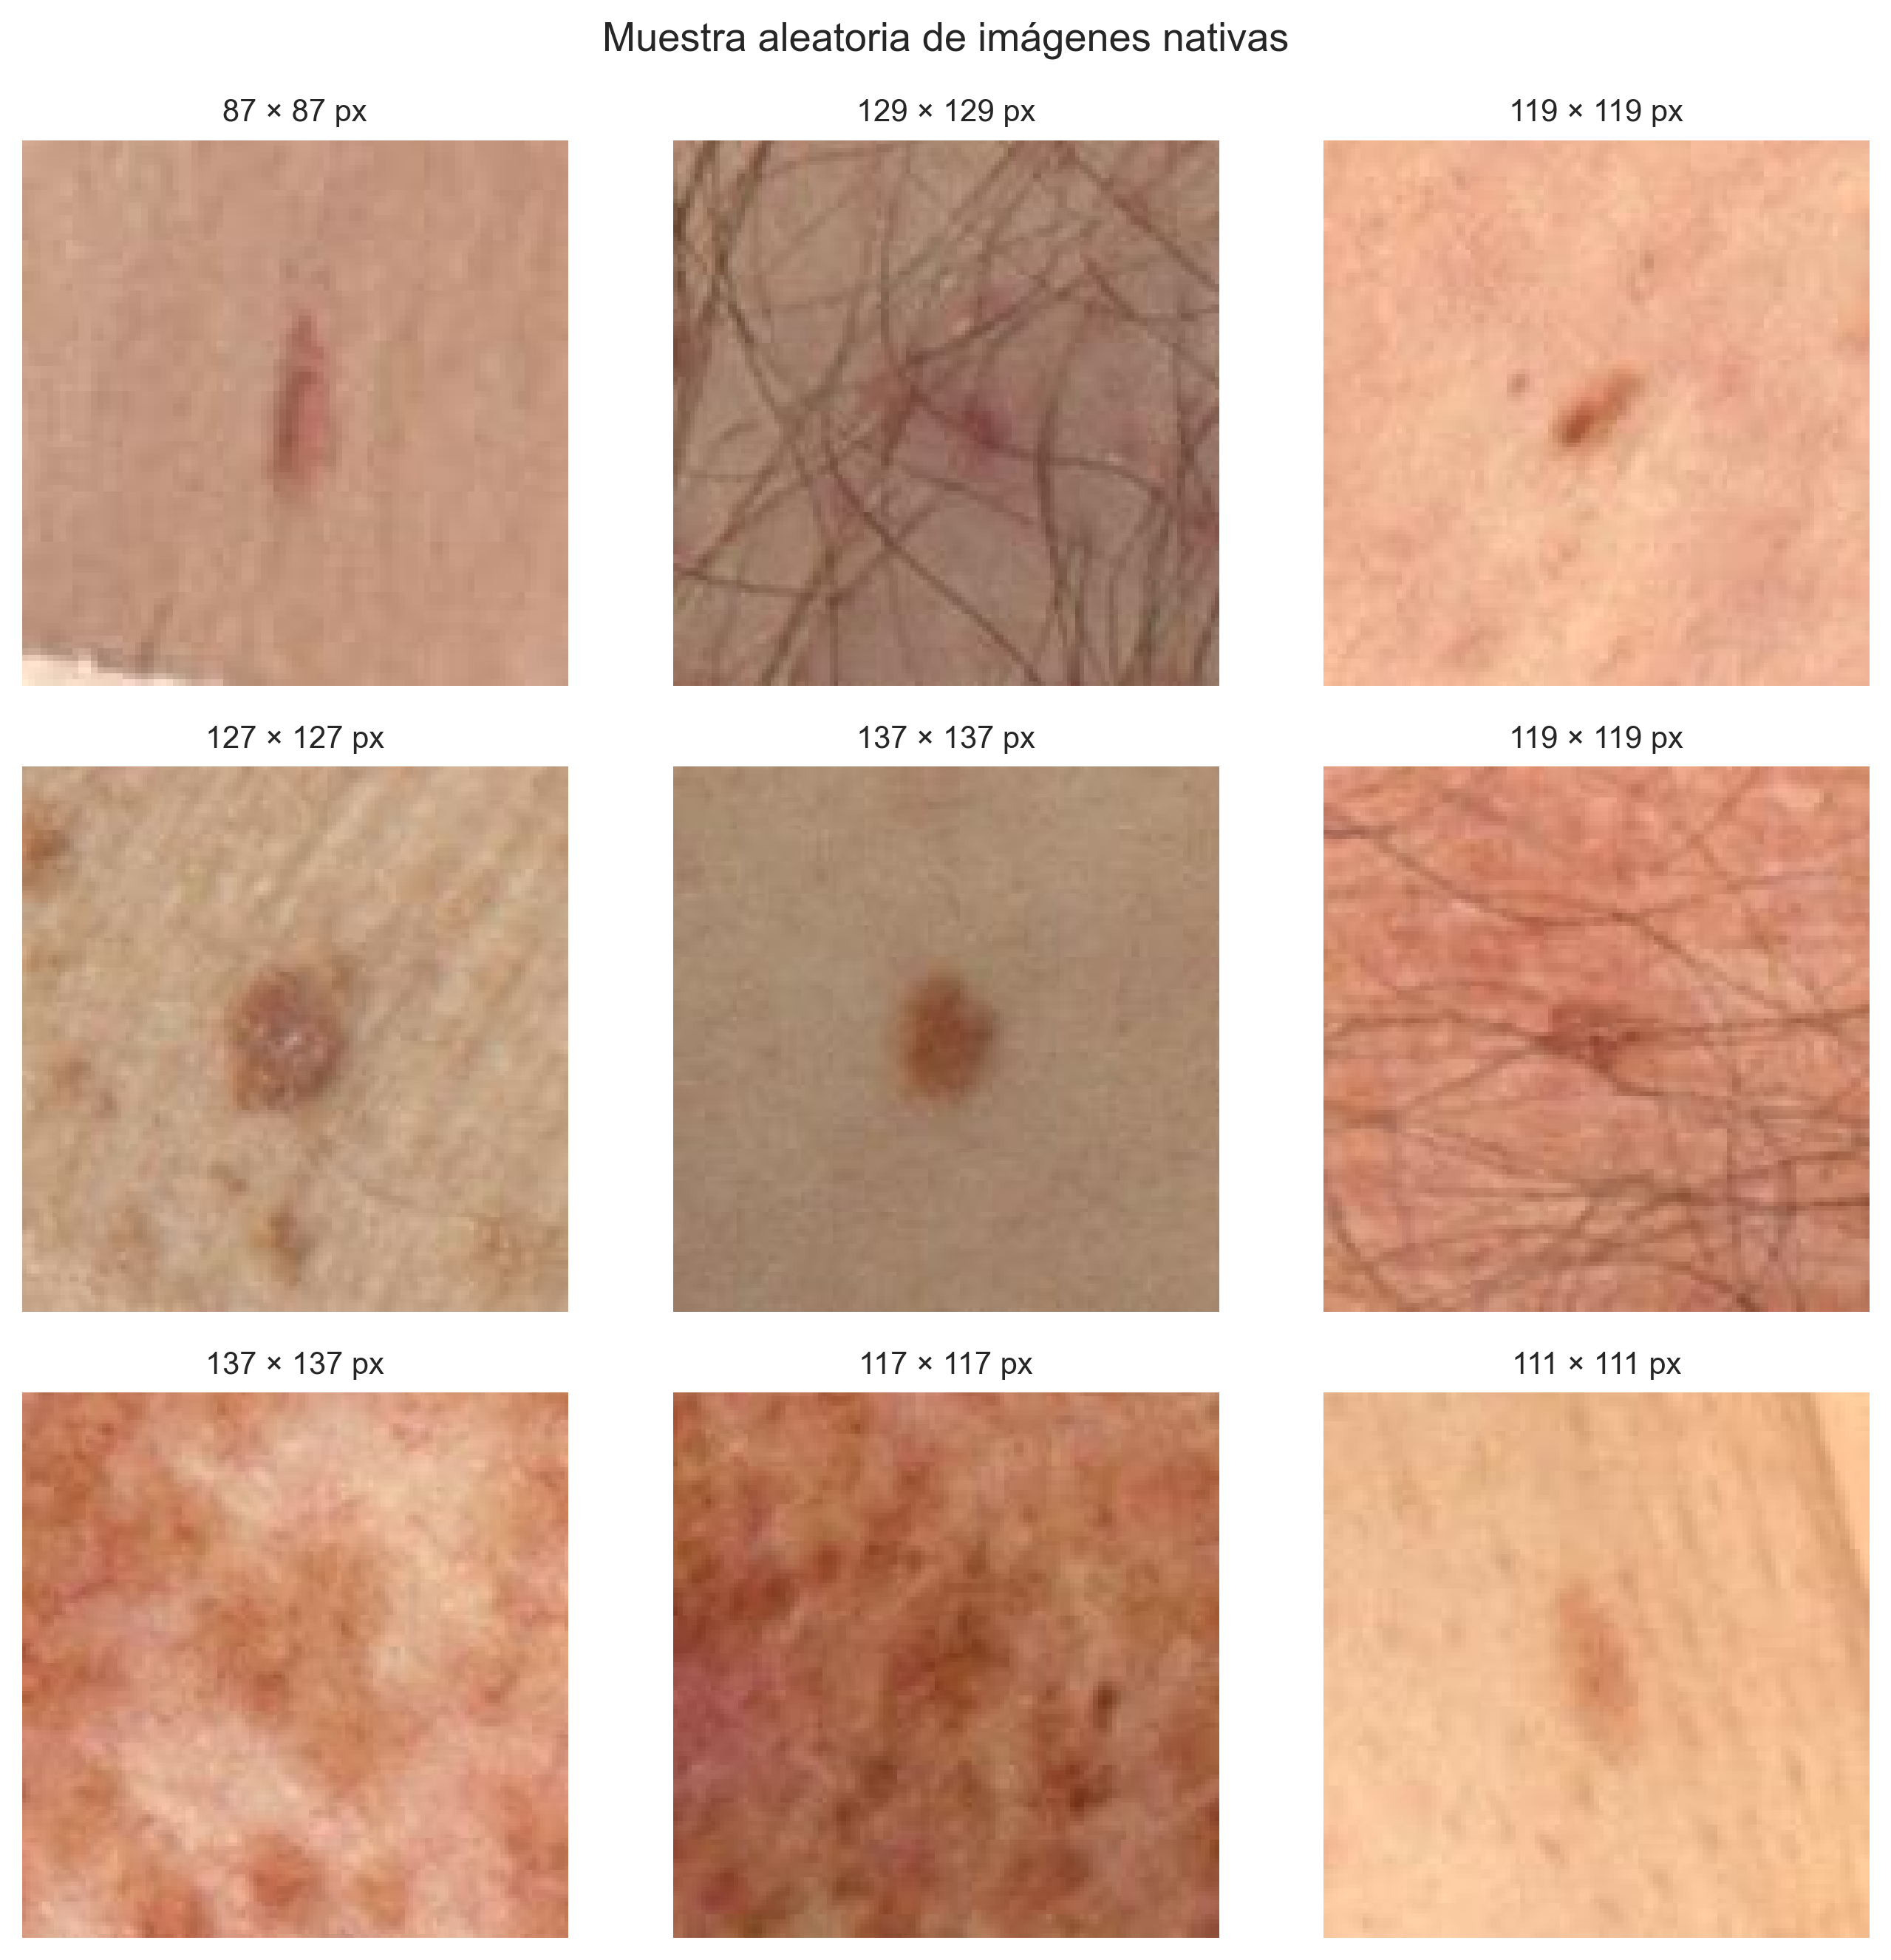

In [46]:
# Display a random 3 x 3 grid of native images

random_images_df = resolution_df.sample(
    n=9,
    replace=False,
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(9, 9),
)

for ax, (_, row) in zip(axes.ravel(), random_images_df.iterrows()):
    img_path = image_path_map[row["image_id"]]

    with Image.open(img_path) as img:
        ax.imshow(img)

    ax.set_title(
        f"{int(row['width'])} × {int(row['height'])} px",
        fontsize=EDA_STYLE["tick_size"],
    )
    ax.axis("off")

plt.suptitle(
    "Muestra aleatoria de imágenes nativas",
    fontsize=EDA_STYLE["title_size"],
)

plt.tight_layout()
plt.show()

In [47]:
# Define representative native-resolution groups

p1 = resolution_df["width"].quantile(0.01)
p5 = resolution_df["width"].quantile(0.05)
p95 = resolution_df["width"].quantile(0.95)

min_width = resolution_df["width"].min()
max_width = resolution_df["width"].max()
median_width = resolution_df["width"].median()

resolution_groups = {
    "Mínimo": resolution_df["width"] == min_width,
    "≤P1": resolution_df["width"] <= p1,
    "P1–P5": (resolution_df["width"] > p1) & (resolution_df["width"] <= p5),
    "Mediana": resolution_df["width"].between(median_width - 2, median_width + 2),
    "≥P95": resolution_df["width"] >= p95,
    "Máximo": resolution_df["width"] == max_width,
}

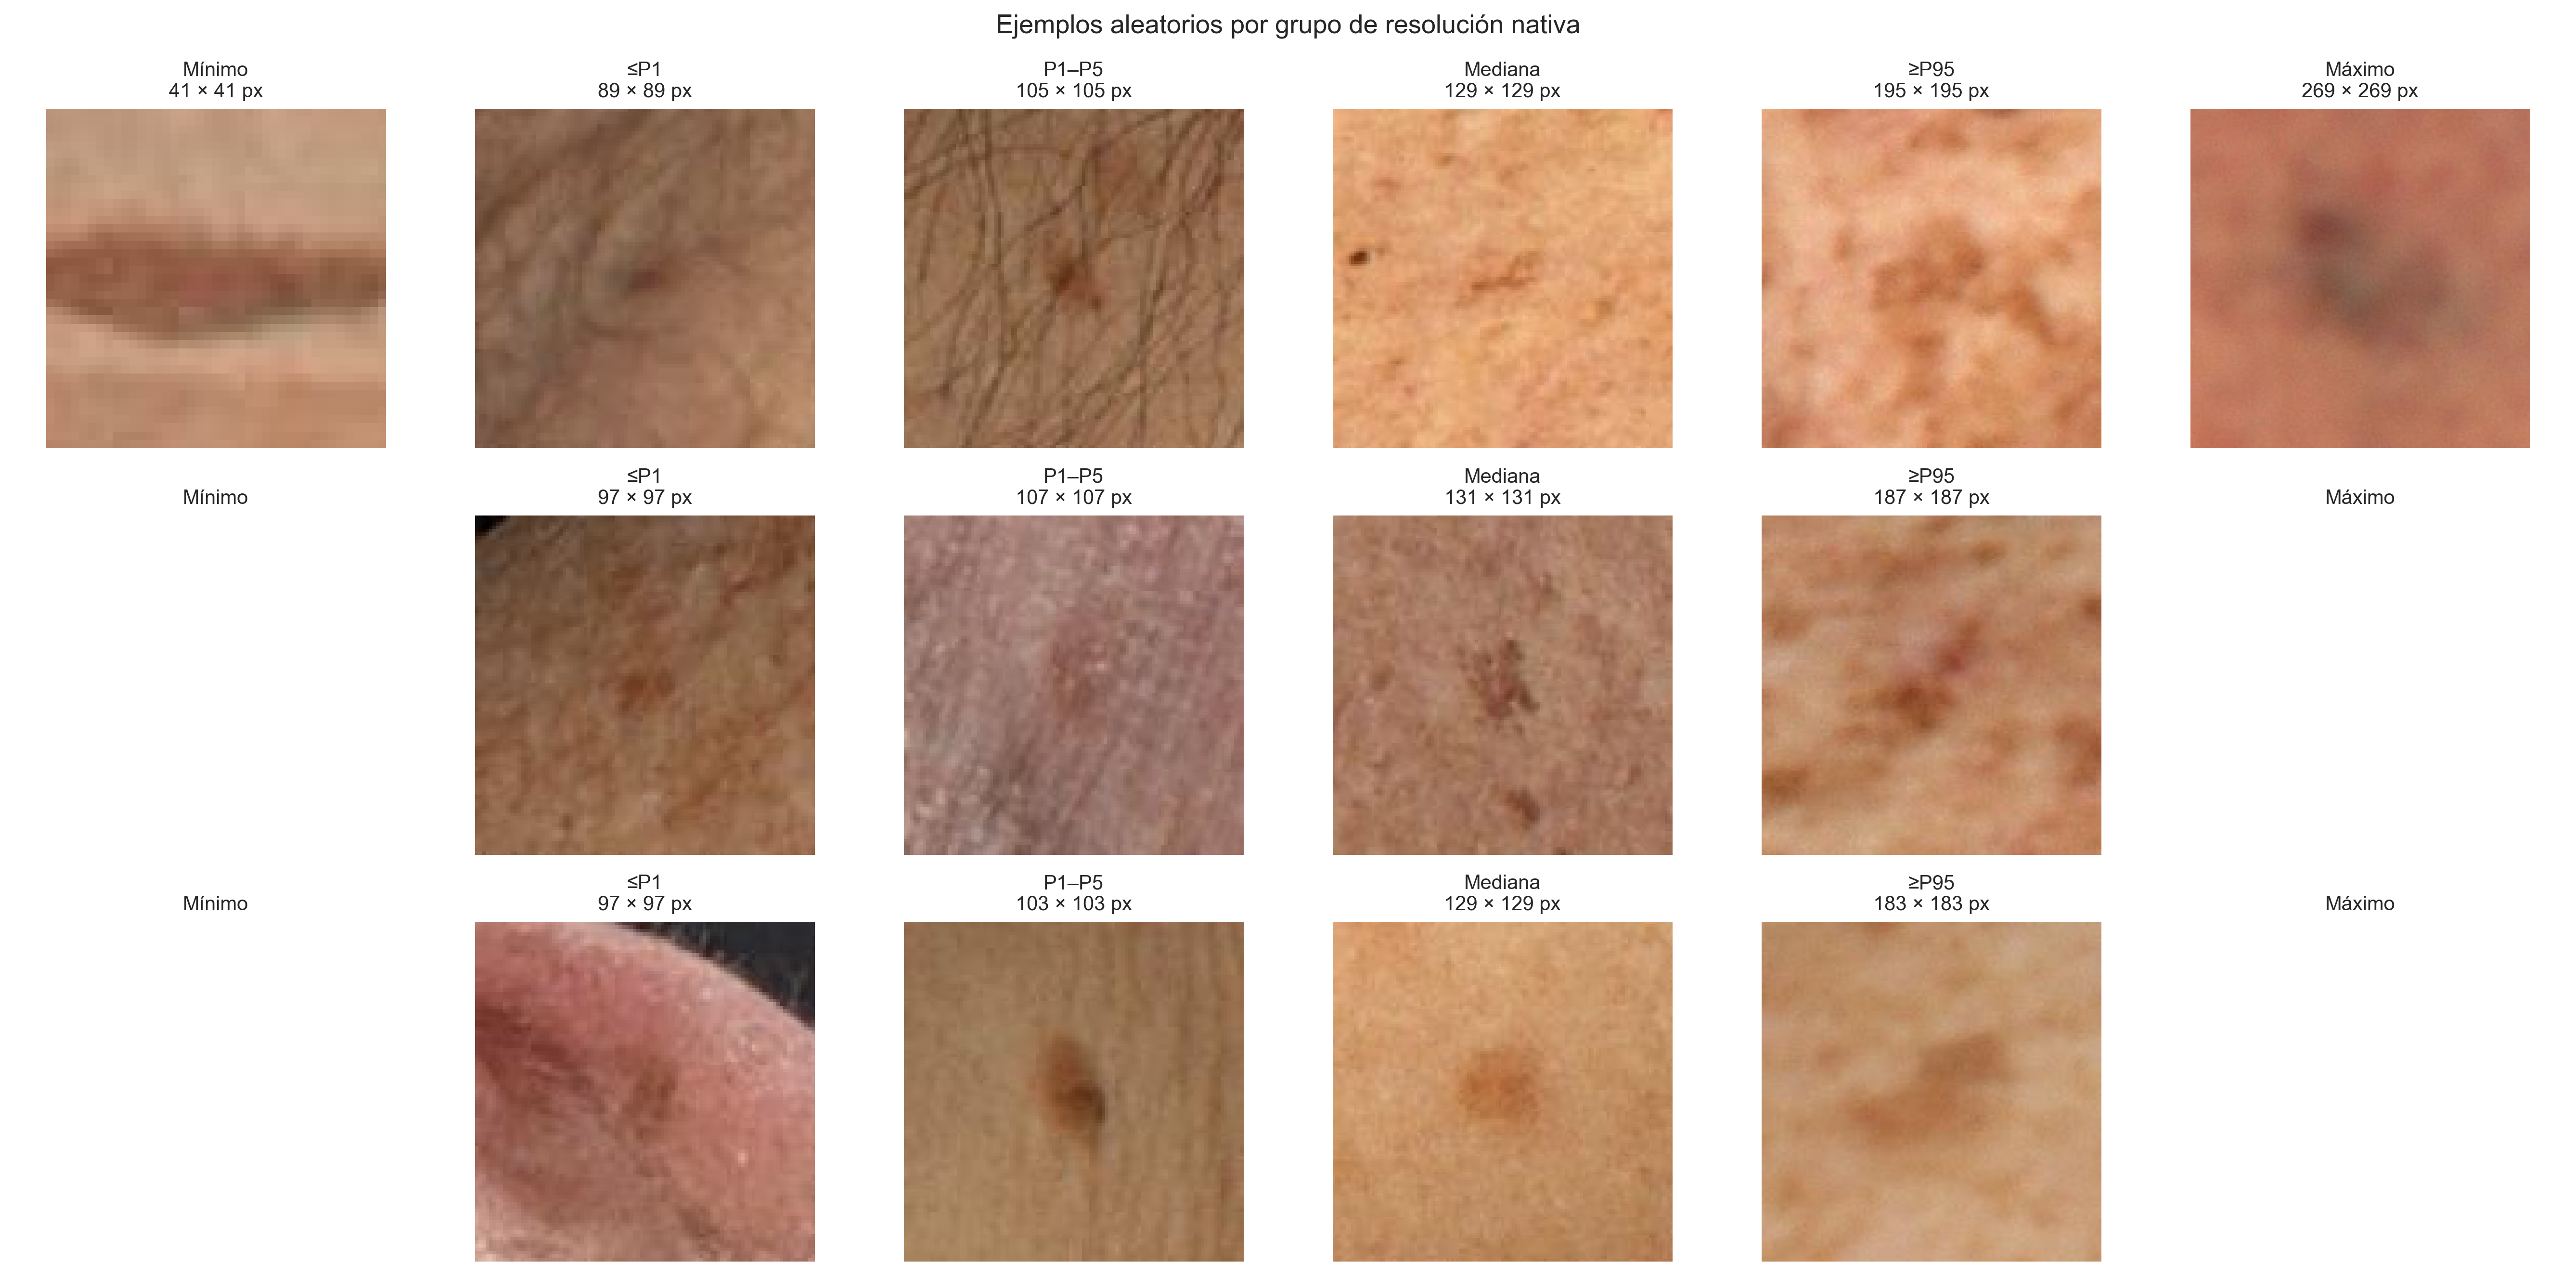

In [90]:
# Display stratified random examples by native-resolution group

n_examples_per_group = 3

sampled_group_dfs = []

for group_label, group_mask in resolution_groups.items():
    group_df = resolution_df.loc[group_mask].copy()

    n_sample = min(n_examples_per_group, len(group_df))

    sampled_df = group_df.sample(
        n=n_sample,
        replace=False,
    )

    sampled_df["resolution_group"] = group_label
    sampled_group_dfs.append(sampled_df)

stratified_visual_df = pd.concat(sampled_group_dfs, ignore_index=True)

fig, axes = plt.subplots(
    n_examples_per_group,
    len(resolution_groups),
    figsize=(18, 9),
)

for col_idx, group_label in enumerate(resolution_groups.keys()):
    group_examples = stratified_visual_df[
        stratified_visual_df["resolution_group"] == group_label
    ].reset_index(drop=True)

    for row_idx in range(n_examples_per_group):
        ax = axes[row_idx, col_idx]

        if row_idx < len(group_examples):
            row = group_examples.loc[row_idx]
            img_path = image_path_map[row["image_id"]]

            with Image.open(img_path) as img:
                ax.imshow(img)

            ax.set_title(
                f"{group_label}\n{int(row['width'])} × {int(row['height'])} px",
                fontsize=EDA_STYLE["tick_size"],
            )
        else:
            ax.set_title(group_label, fontsize=EDA_STYLE["tick_size"])

        ax.axis("off")

plt.suptitle(
    "Ejemplos aleatorios por grupo de resolución nativa",
    fontsize=EDA_STYLE["title_size"],
)

figures["native_image_examples_by_resolution"] = fig

plt.tight_layout()
plt.show()

### Quantitative Resize Impact

For each candidate input size, the required scale factor was computed as:

target input size / native image width.

A scale factor above 1 indicates upsampling, while a scale factor below 1 indicates downsampling. This distinction is important because upsampling increases image size through interpolation but does not add new visual information.

This analysis quantifies how many images would be upsampled, downsampled or left unchanged for each candidate size.

In [51]:
# Quantify resize impact for each candidate input size

resize_impact_summary = []

for size in candidate_sizes:
    scale_factor = size / resolution_df["width"]

    n_upsampled = (scale_factor > 1).sum()
    n_downsampled = (scale_factor < 1).sum()
    n_unchanged = (scale_factor == 1).sum()

    resize_impact_summary.append(
        {
            "input_size": size,
            "upsampled_n": n_upsampled,
            "upsampled_pct": n_upsampled / len(resolution_df) * 100,
            "downsampled_n": n_downsampled,
            "downsampled_pct": n_downsampled / len(resolution_df) * 100,
            "unchanged_n": n_unchanged,
            "unchanged_pct": n_unchanged / len(resolution_df) * 100,
            "median_scale_factor": scale_factor.median(),
            "p95_scale_factor": scale_factor.quantile(0.95),
            "max_scale_factor": scale_factor.max(),
        }
    )

resize_impact_df = pd.DataFrame(resize_impact_summary)

print(resize_impact_df.round(3))

   input_size  upsampled_n  upsampled_pct  downsampled_n  downsampled_pct  \
0          96         3547          0.884         397512           99.116   
1         128       160794         40.092         240265           59.908   
2         160       372461         92.869          28598            7.131   
3         192       397561         99.128           3498            0.872   
4         224       400766         99.927            293            0.073   

   unchanged_n  unchanged_pct  median_scale_factor  p95_scale_factor  \
0            0            0.0                0.733             0.897   
1            0            0.0                0.977             1.196   
2            0            0.0                1.221             1.495   
3            0            0.0                1.466             1.794   
4            0            0.0                1.710             2.093   

   max_scale_factor  
0             2.341  
1             3.122  
2             3.902  
3             4.

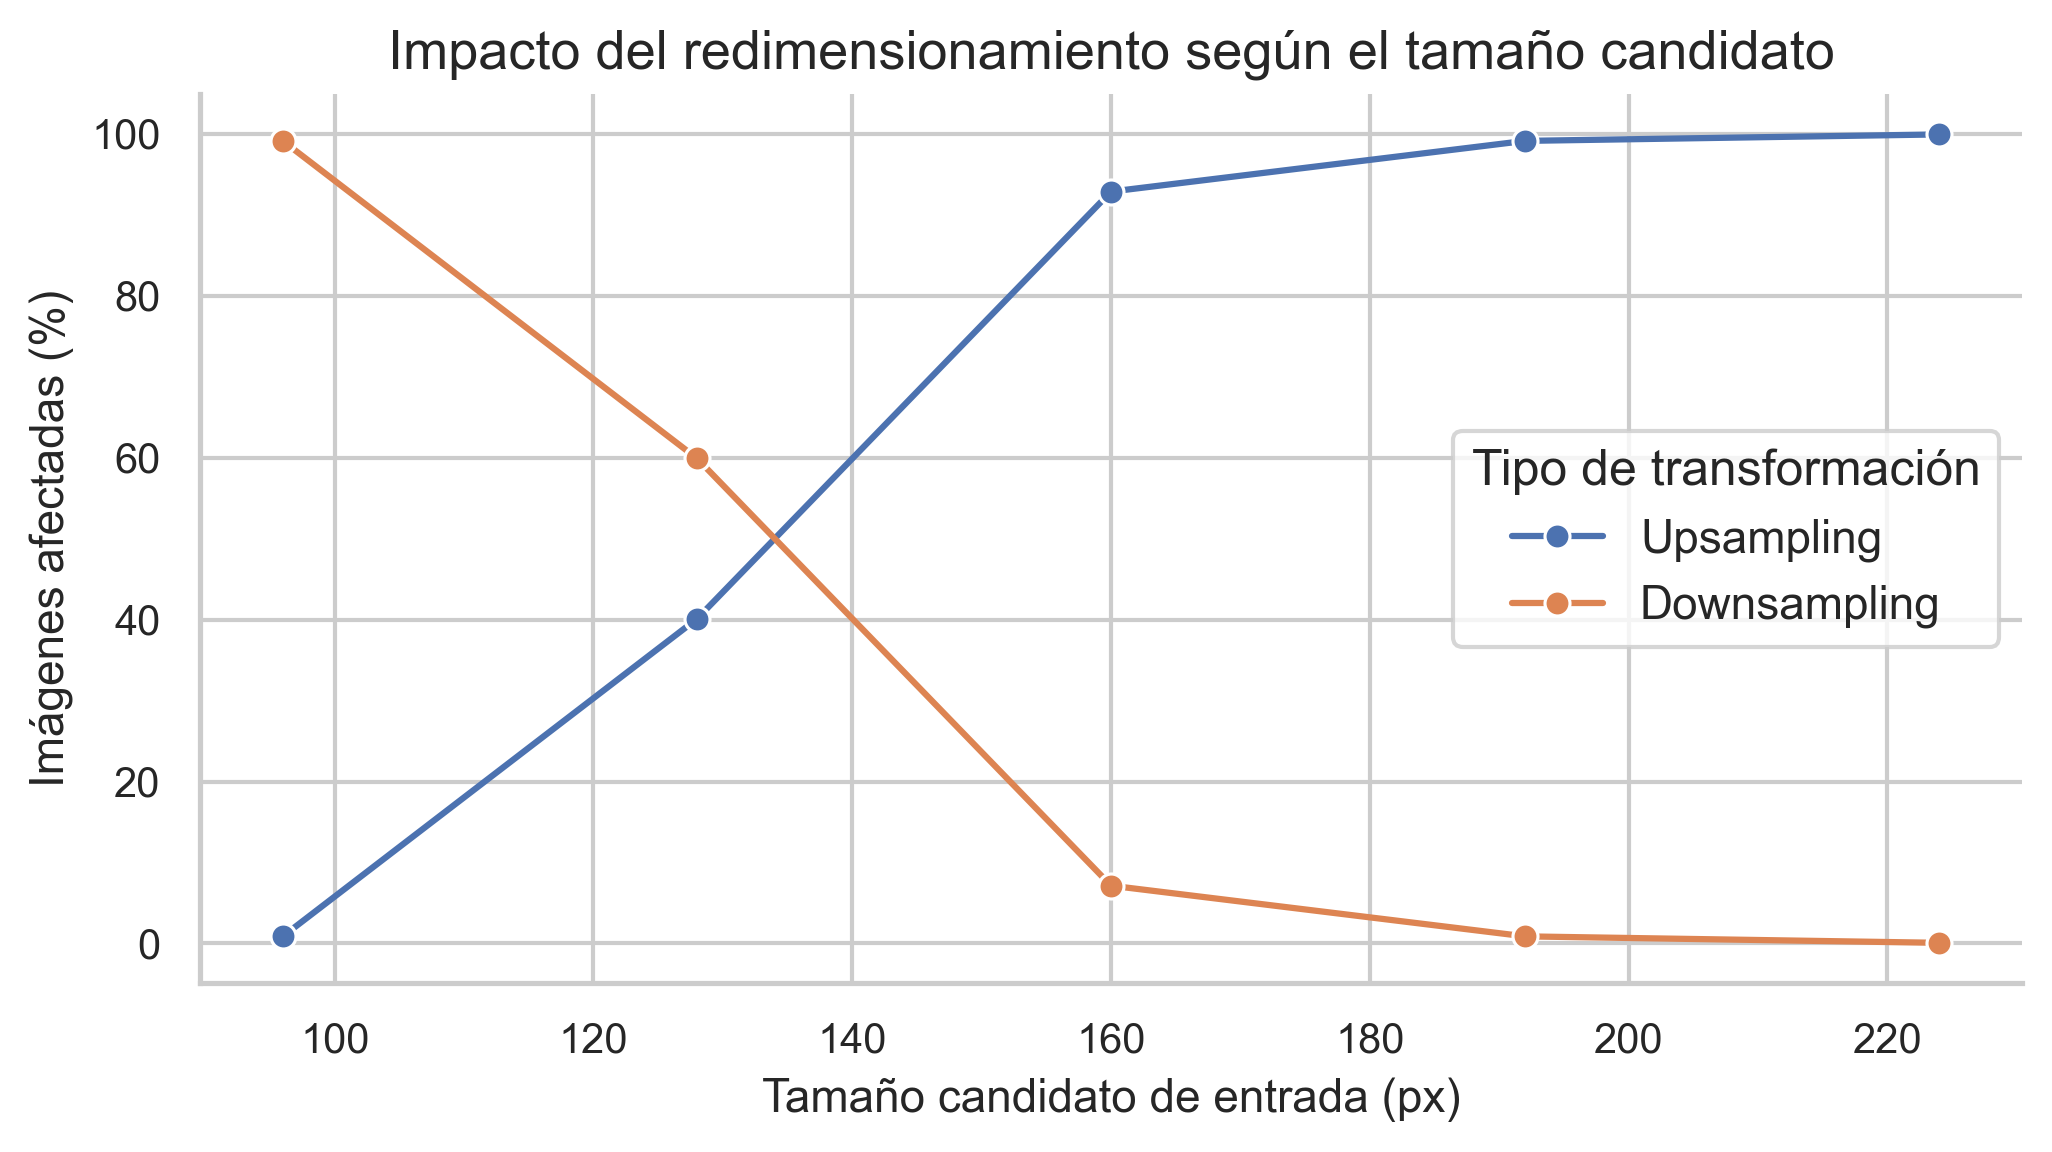

In [52]:
# Plot resize direction by candidate input size

resize_direction_plot_df = resize_impact_df.melt(
    id_vars="input_size",
    value_vars=["upsampled_pct", "downsampled_pct"],
    var_name="resize_direction",
    value_name="percentage",
)

resize_direction_plot_df["resize_direction"] = resize_direction_plot_df[
    "resize_direction"
].map(
    {
        "upsampled_pct": "Upsampling",
        "downsampled_pct": "Downsampling",
    }
)

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.lineplot(
    data=resize_direction_plot_df,
    x="input_size",
    y="percentage",
    hue="resize_direction",
    marker="o",
    ax=ax,
)

clean_axis_labels(
    ax,
    xlabel="Tamaño candidato de entrada (px)",
    ylabel="Imágenes afectadas (%)",
    title="Impacto del redimensionamiento según el tamaño candidato",
)

ax.legend(title="Tipo de transformación")

plt.tight_layout()
plt.show()

The resize impact analysis shows marked differences between candidate input sizes.

At 96 × 96, almost all images would be downsampled (99.12%), making this option computationally efficient but potentially associated with loss of spatial detail. In contrast, larger input sizes increasingly require upsampling: 160 × 160 would upsample 92.87% of images, while 192 × 192 and 224 × 224 would require upsampling for almost the entire dataset.

The 128 × 128 candidate provides the most balanced resizing behaviour among the evaluated options, with 40.09% of images requiring upsampling and 59.91% requiring downsampling. This is consistent with the native image resolution distribution, whose median is close to 131 px. Therefore, the transition point between predominantly downsampling and predominantly upsampling lies around the central native resolution of the dataset.

From a preprocessing perspective, 128 × 128 appears to be the most conservative candidate size because it is close to the native resolution of many images and avoids extensive upsampling. By contrast, 160 × 160 and larger sizes may preserve more spatial detail for higher-resolution images, but they would introduce upsampling for most of the dataset. These larger candidates should therefore be evaluated carefully in terms of upsampling severity, storage requirements and downstream model performance.

The plot visually confirms this pattern: the proportion of upsampled images increases rapidly as the candidate input size moves above the central native resolution range, while the proportion of downsampled images decreases accordingly.

### Fine-Grained Analysis Around the Native Median Resolution

The previous analysis showed that the transition between predominantly downsampling and predominantly upsampling occurs around the central native resolution of the dataset.

Since the median native resolution is 131 × 131 pixels, a finer analysis was performed around this range. This allows evaluation of intermediate candidate sizes between 128 × 128 and 160 × 160, where the trade-off between preserving spatial detail and avoiding excessive upsampling is most relevant.

This analysis is exploratory and aims to identify additional candidate input sizes that may be worth carrying forward to the storage and computational cost analysis.

In [54]:
# Fine-grained resize impact around the central native resolution

fine_candidate_sizes = [112, 120, 128, 136, 144, 152, 160]

fine_resize_impact_summary = []

for size in fine_candidate_sizes:
    scale_factor = size / resolution_df["width"]

    n_upsampled = (scale_factor > 1).sum()
    n_downsampled = (scale_factor < 1).sum()
    n_unchanged = (scale_factor == 1).sum()

    fine_resize_impact_summary.append(
        {
            "input_size": size,
            "upsampled_n": n_upsampled,
            "upsampled_pct": n_upsampled / len(resolution_df) * 100,
            "downsampled_n": n_downsampled,
            "downsampled_pct": n_downsampled / len(resolution_df) * 100,
            "unchanged_n": n_unchanged,
            "unchanged_pct": n_unchanged / len(resolution_df) * 100,
            "median_scale_factor": scale_factor.median(),
            "p95_scale_factor": scale_factor.quantile(0.95),
            "max_scale_factor": scale_factor.max(),
        }
    )

fine_resize_impact_df = pd.DataFrame(fine_resize_impact_summary)

print(fine_resize_impact_df.round(3))

   input_size  upsampled_n  upsampled_pct  downsampled_n  downsampled_pct  \
0         112        40611         10.126         360448           89.874   
1         120        90696         22.614         310363           77.386   
2         128       160794         40.092         240265           59.908   
3         136       243492         60.712         157567           39.288   
4         144       306937         76.532          94122           23.468   
5         152       344610         85.925          56449           14.075   
6         160       372461         92.869          28598            7.131   

   unchanged_n  unchanged_pct  median_scale_factor  p95_scale_factor  \
0            0            0.0                0.855             1.047   
1            0            0.0                0.916             1.121   
2            0            0.0                0.977             1.196   
3            0            0.0                1.038             1.271   
4            0         

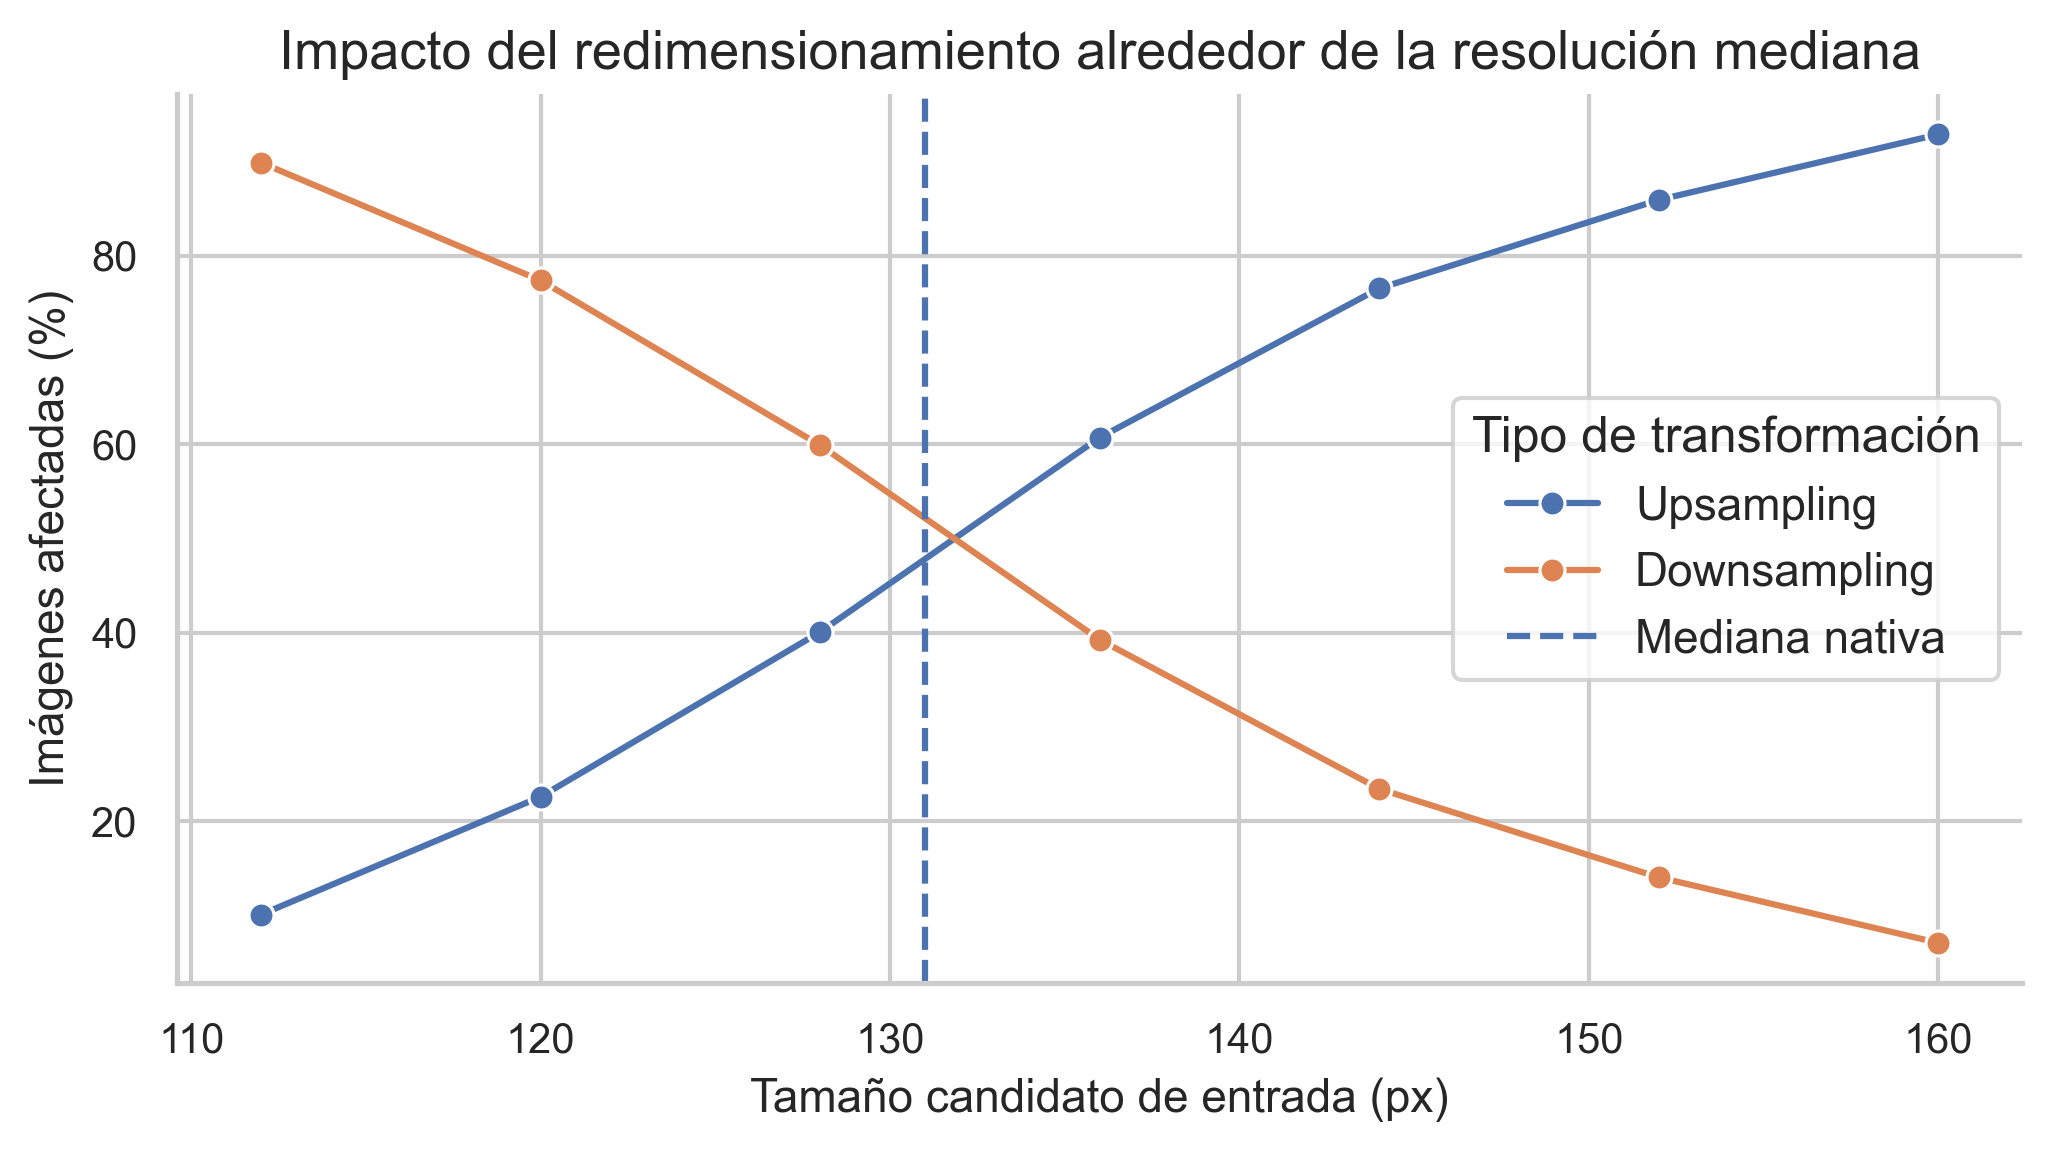

In [87]:
# Plot fine-grained resize impact around the median native resolution

fine_resize_plot_df = fine_resize_impact_df.melt(
    id_vars="input_size",
    value_vars=["upsampled_pct", "downsampled_pct"],
    var_name="resize_direction",
    value_name="percentage",
)

fine_resize_plot_df["resize_direction"] = fine_resize_plot_df["resize_direction"].map(
    {
        "upsampled_pct": "Upsampling",
        "downsampled_pct": "Downsampling",
    }
)

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.lineplot(
    data=fine_resize_plot_df,
    x="input_size",
    y="percentage",
    hue="resize_direction",
    marker="o",
    ax=ax,
)

ax.axvline(
    resolution_df["width"].median(),
    linestyle="--",
    linewidth=1.5,
    label="Mediana nativa",
)

clean_axis_labels(
    ax,
    xlabel="Tamaño candidato de entrada (px)",
    ylabel="Imágenes afectadas (%)",
    title="Impacto del redimensionamiento alrededor de la resolución mediana",
)

ax.legend(title="Tipo de transformación")
figures["fine_resize_impact"] = fig
plt.tight_layout()
plt.show()

The fine-grained analysis confirms that the transition between predominantly downsampling and predominantly upsampling occurs around the central native resolution of the dataset.

At 128 × 128, 40.09% of images would require upsampling and 59.91% would require downsampling. This makes 128 × 128 the most conservative candidate among the evaluated sizes, as it remains close to the median native resolution while limiting the proportion of images that require enlargement.

At 136 × 136, the balance shifts slightly towards upsampling, with 60.71% of images upsampled and 39.29% downsampled. This candidate lies close to the empirical transition point between both transformations and may represent a useful compromise between preserving spatial detail and avoiding excessive upsampling.

At 144 × 144, 76.53% of images would require upsampling. Although this is substantially higher than for 128 × 128 or 136 × 136, the median scale factor remains moderate (1.10×), suggesting that most upsampling would still be relatively mild. Therefore, 144 × 144 may be considered as an intermediate higher-resolution candidate, but it should be evaluated carefully in terms of storage, computational cost and upsampling severity.

Larger sizes such as 152 × 152 and 160 × 160 lead to progressively higher upsampling rates, affecting 85.93% and 92.87% of images, respectively. Although these sizes may preserve more detail for high-resolution images, they are less aligned with the native resolution distribution and may introduce unnecessary interpolation for most of the dataset.

Overall, the most relevant candidates to carry forward are 128 × 128, 136 × 136 and 144 × 144. The 128 × 128 size should be considered the conservative baseline, 136 × 136 the most balanced option, and 144 × 144 a higher-resolution compromise. The 160 × 160 size may still be retained as an upper reference, while 192 × 192 and 224 × 224 should mainly be considered for compatibility with pretrained architectures rather than as natural choices for this dataset.

In [56]:
# Candidate sizes retained after fine-grained resize impact analysis

primary_candidate_sizes = [128, 136, 144]

reference_candidate_sizes = [96, 160, 224]

candidate_sizes = primary_candidate_sizes + reference_candidate_sizes

candidate_sizes

[128, 136, 144, 96, 160, 224]

Based on the fine-grained resize impact analysis, three primary candidate input sizes were retained: 128 × 128, 136 × 136 and 144 × 144.

The 128 × 128 size is retained as the conservative baseline, because it is closest to the native median resolution and minimizes unnecessary upsampling. The 136 × 136 size is retained as the most balanced candidate, located near the transition between predominantly downsampling and predominantly upsampling. The 144 × 144 size is retained as an intermediate higher-resolution option, offering more spatial detail at the cost of a higher proportion of mildly upsampled images.

Additional reference sizes are also kept for comparison. The 96 × 96 size represents a lightweight low-resolution baseline, while 160 × 160 provides an upper intermediate reference. The 224 × 224 size is retained mainly because of its relevance for pretrained computer vision architectures, although it is less aligned with the native resolution distribution of this dataset.

### Upsampling Severity

After identifying the most relevant candidate input sizes, the next step was to quantify the severity of upsampling required by each option.

This analysis is important because upsampling enlarges the image through interpolation but does not recover missing spatial information. Mild upsampling may be acceptable, but strong upsampling can amplify pixelation or reduce the amount of useful visual detail available to the model.

Two thresholds were used:

- >1.5× upsampling: relevant upsampling.
- >2× upsampling: extreme upsampling.

These thresholds are used as inspection flags, not as automatic exclusion criteria.

In [58]:
# Assess upsampling severity for retained candidate input sizes

upsampling_severity_summary = []

for size in candidate_sizes:
    scale_factor = size / resolution_df["width"]

    n_any_upsampling = (scale_factor > 1).sum()
    n_gt_1_5 = (scale_factor > 1.5).sum()
    n_gt_2 = (scale_factor > 2).sum()

    upsampling_severity_summary.append(
        {
            "input_size": size,
            "candidate_type": (
                "primary" if size in primary_candidate_sizes else "reference"
            ),
            "any_upsampling_n": n_any_upsampling,
            "any_upsampling_pct": n_any_upsampling / len(resolution_df) * 100,
            "upsampling_gt_1_5x_n": n_gt_1_5,
            "upsampling_gt_1_5x_pct": n_gt_1_5 / len(resolution_df) * 100,
            "upsampling_gt_2x_n": n_gt_2,
            "upsampling_gt_2x_pct": n_gt_2 / len(resolution_df) * 100,
            "native_width_threshold_for_1_5x": size / 1.5,
            "native_width_threshold_for_2x": size / 2,
        }
    )

upsampling_severity_df = pd.DataFrame(upsampling_severity_summary)

print(upsampling_severity_df.round(3))

   input_size candidate_type  any_upsampling_n  any_upsampling_pct  \
0         128        primary            160794              40.092   
1         136        primary            243492              60.712   
2         144        primary            306937              76.532   
3          96      reference              3547               0.884   
4         160      reference            372461              92.869   
5         224      reference            400766              99.927   

   upsampling_gt_1_5x_n  upsampling_gt_1_5x_pct  upsampling_gt_2x_n  \
0                  1074                   0.268                  86   
1                  1671                   0.417                 148   
2                  3547                   0.884                 243   
3                    86                   0.021                   5   
4                 17318                   4.318                 572   
5                336244                  83.839               40611   

   upsampli

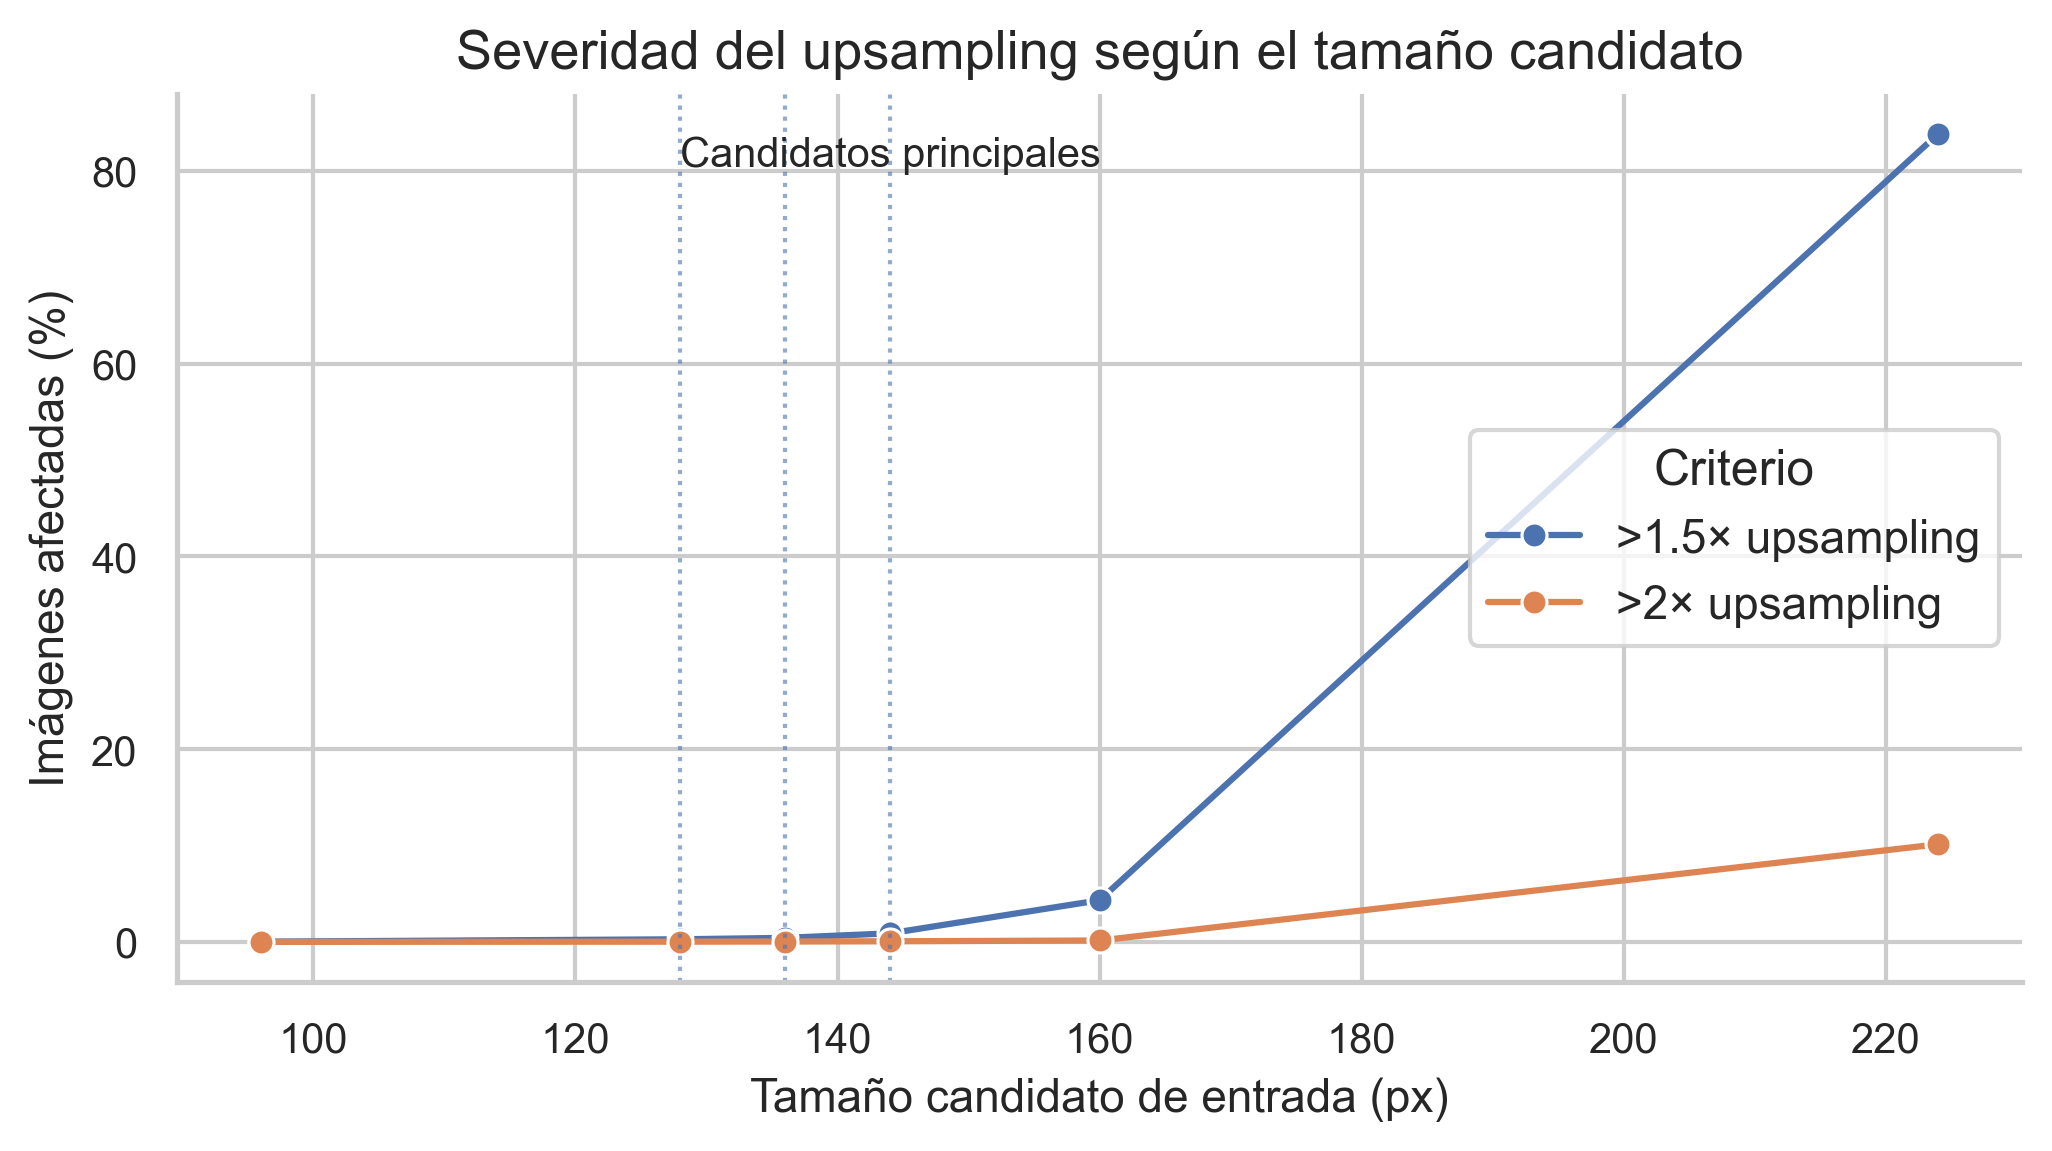

In [60]:
# Plot upsampling severity by candidate input size

upsampling_plot_df = upsampling_severity_df.melt(
    id_vars=["input_size", "candidate_type"],
    value_vars=[
        "upsampling_gt_1_5x_pct",
        "upsampling_gt_2x_pct",
    ],
    var_name="upsampling_threshold",
    value_name="percentage",
)

upsampling_plot_df["upsampling_threshold"] = upsampling_plot_df[
    "upsampling_threshold"
].map(
    {
        "upsampling_gt_1_5x_pct": ">1.5× upsampling",
        "upsampling_gt_2x_pct": ">2× upsampling",
    }
)

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.lineplot(
    data=upsampling_plot_df,
    x="input_size",
    y="percentage",
    hue="upsampling_threshold",
    marker="o",
    ax=ax,
)

for size in primary_candidate_sizes:
    ax.axvline(
        size,
        linestyle=":",
        linewidth=1,
        alpha=0.6,
    )

ax.text(
    128,
    ax.get_ylim()[1] * 0.95,
    "Candidatos principales",
    ha="left",
    va="top",
    fontsize=EDA_STYLE["tick_size"],
)

clean_axis_labels(
    ax,
    xlabel="Tamaño candidato de entrada (px)",
    ylabel="Imágenes afectadas (%)",
    title="Severidad del upsampling según el tamaño candidato",
)

ax.legend(title="Criterio")

plt.tight_layout()
plt.show()

The upsampling severity analysis shows that the three primary candidate sizes remain reasonable from a preprocessing perspective.

Although 128 × 128, 136 × 136 and 144 × 144 require upsampling for an increasing proportion of images, severe upsampling is rare in all three cases. For 128 × 128, only 0.27% of images would require >1.5× upsampling and 0.02% would require >2× upsampling. For 136 × 136, these values increase slightly to 0.42% and 0.04%, respectively. For 144 × 144, >1.5× upsampling affects 0.88% of images, while >2× upsampling remains very limited at 0.06%.

This suggests that the main difference between the primary candidates is not the presence of extreme upsampling, but the overall proportion of images that undergo mild enlargement. Therefore, 144 × 144 remains a plausible higher-resolution candidate, provided that its storage and computational cost are acceptable.

The 160 × 160 reference size shows a larger but still relatively limited proportion of severe upsampling, with 4.32% of images requiring >1.5× enlargement and 0.14% requiring >2× enlargement. This makes it useful as an upper intermediate reference, but less conservative than the primary candidates.

In contrast, 224 × 224 is poorly aligned with the native resolution distribution. More than 80% of images would require >1.5× upsampling and 10.13% would require >2× upsampling. Therefore, this size should mainly be considered for pretrained model compatibility rather than as a natural resizing choice for this dataset.

Overall, these results support retaining 128 × 128, 136 × 136 and 144 × 144 as the main candidate sizes. No image should be excluded automatically based on these thresholds, but images requiring >2× upsampling should be flagged for targeted visual inspection and possible sensitivity analyses.

### Candidate Images for Visual Inspection

For each retained input size, images requiring extreme upsampling were identified using a scale factor >2.

These images are not removed automatically. Instead, their lesion identifiers are extracted so that they can be visually inspected and, if necessary, evaluated in later sensitivity analyses.

This step is especially relevant for comparing candidate sizes: if a given input size produces many images requiring >2× upsampling, it may be less appropriate as a default preprocessing choice.

In [61]:
# Extract lesion IDs requiring extreme upsampling for each candidate input size

extreme_upsampling_candidates = {}

for size in candidate_sizes:
    scale_factor = size / resolution_df["width"]

    candidates = (
        resolution_df.loc[scale_factor > 2]
        .copy()
        .rename(columns={"image_id": "lesion_id"})
        .sort_values("width")
    )

    candidates["input_size"] = size
    candidates["scale_factor"] = size / candidates["width"]
    candidates["candidate_type"] = (
        "primary" if size in primary_candidate_sizes else "reference"
    )

    extreme_upsampling_candidates[size] = candidates

    print(
        f"{size} × {size}: "
        f"{len(candidates):,} images require >2× upsampling "
        f"({len(candidates) / len(resolution_df) * 100:.3f}%)"
    )

128 × 128: 86 images require >2× upsampling (0.021%)
136 × 136: 148 images require >2× upsampling (0.037%)
144 × 144: 243 images require >2× upsampling (0.061%)
96 × 96: 5 images require >2× upsampling (0.001%)
160 × 160: 572 images require >2× upsampling (0.143%)
224 × 224: 40,611 images require >2× upsampling (10.126%)


In [63]:
# Summarize extreme upsampling candidates by input size

extreme_upsampling_summary = pd.DataFrame(
    [
        {
            "input_size": size,
            "candidate_type": (
                "primary" if size in primary_candidate_sizes else "reference"
            ),
            "n_extreme_upsampling": len(candidates),
            "pct_extreme_upsampling": len(candidates) / len(resolution_df) * 100,
        }
        for size, candidates in extreme_upsampling_candidates.items()
    ]
)

print(extreme_upsampling_summary.round(3))

   input_size candidate_type  n_extreme_upsampling  pct_extreme_upsampling
0         128        primary                    86                   0.021
1         136        primary                   148                   0.037
2         144        primary                   243                   0.061
3          96      reference                     5                   0.001
4         160      reference                   572                   0.143
5         224      reference                 40611                  10.126


The extraction of extreme upsampling candidates confirms that very few images would require >2× enlargement for the primary candidate sizes.

For 128 × 128, only 86 images would require >2× upsampling, representing 0.02% of the dataset. This increases slightly to 148 images (0.04%) for 136 × 136 and 243 images (0.06%) for 144 × 144. Therefore, the three primary candidates produce only a negligible number of extreme upsampling cases.

The 160 × 160 reference size also shows a relatively small number of extreme cases, with 572 images affected (0.14%). However, this is higher than for the primary candidates and should be interpreted together with its higher overall upsampling rate.

In contrast, 224 × 224 would produce 40,611 extreme upsampling cases, affecting 10.13% of the dataset. This confirms that 224 × 224 is poorly aligned with the native resolution distribution and should not be considered a natural default size for this dataset, unless required by a specific pretrained model architecture.

Overall, no automatic exclusion is justified for 128 × 128, 136 × 136 or 144 × 144 based on extreme upsampling alone. The affected images should instead be flagged for visual inspection and possible sensitivity analyses, especially if 144 × 144 or larger input sizes are selected.

### Visual Comparison After Resizing

Representative images from the lowest and central parts of the native resolution distribution were resized to the main candidate input sizes.

This visual comparison is qualitative. The goal is to assess whether larger target sizes appear to add useful visual detail or mainly introduce interpolation, especially in low-resolution images.

The comparison focuses on 128 × 128, 136 × 136 and 144 × 144 as primary candidates. The 160 × 160 and 224 × 224 sizes are included as higher-resolution references.

In [66]:
# Select images for visual resize comparison

comparison_labels = ["Mínimo", "≤P1", "P1–P5", "Mediana"]

# Use previously defined resolution groups to sample one image per group
resize_comparison_images = []

for group_label in comparison_labels:
    group_mask = resolution_groups[group_label]
    group_df = resolution_df.loc[group_mask].copy()

    sampled_row = group_df.sample(n=1).iloc[0]
    sampled_row["resolution_group"] = group_label

    resize_comparison_images.append(sampled_row)

resize_comparison_df = pd.DataFrame(resize_comparison_images)

print(
    resize_comparison_df[
        ["resolution_group", "image_id", "width", "height", "aspect_ratio"]
    ]
)

       resolution_group      image_id  width  height  aspect_ratio
7543             Mínimo  ISIC_0259506     41      41           1.0
3937                ≤P1  ISIC_0169482     89      89           1.0
249858            P1–P5  ISIC_6278351    105     105           1.0
92782           Mediana  ISIC_2371597    131     131           1.0


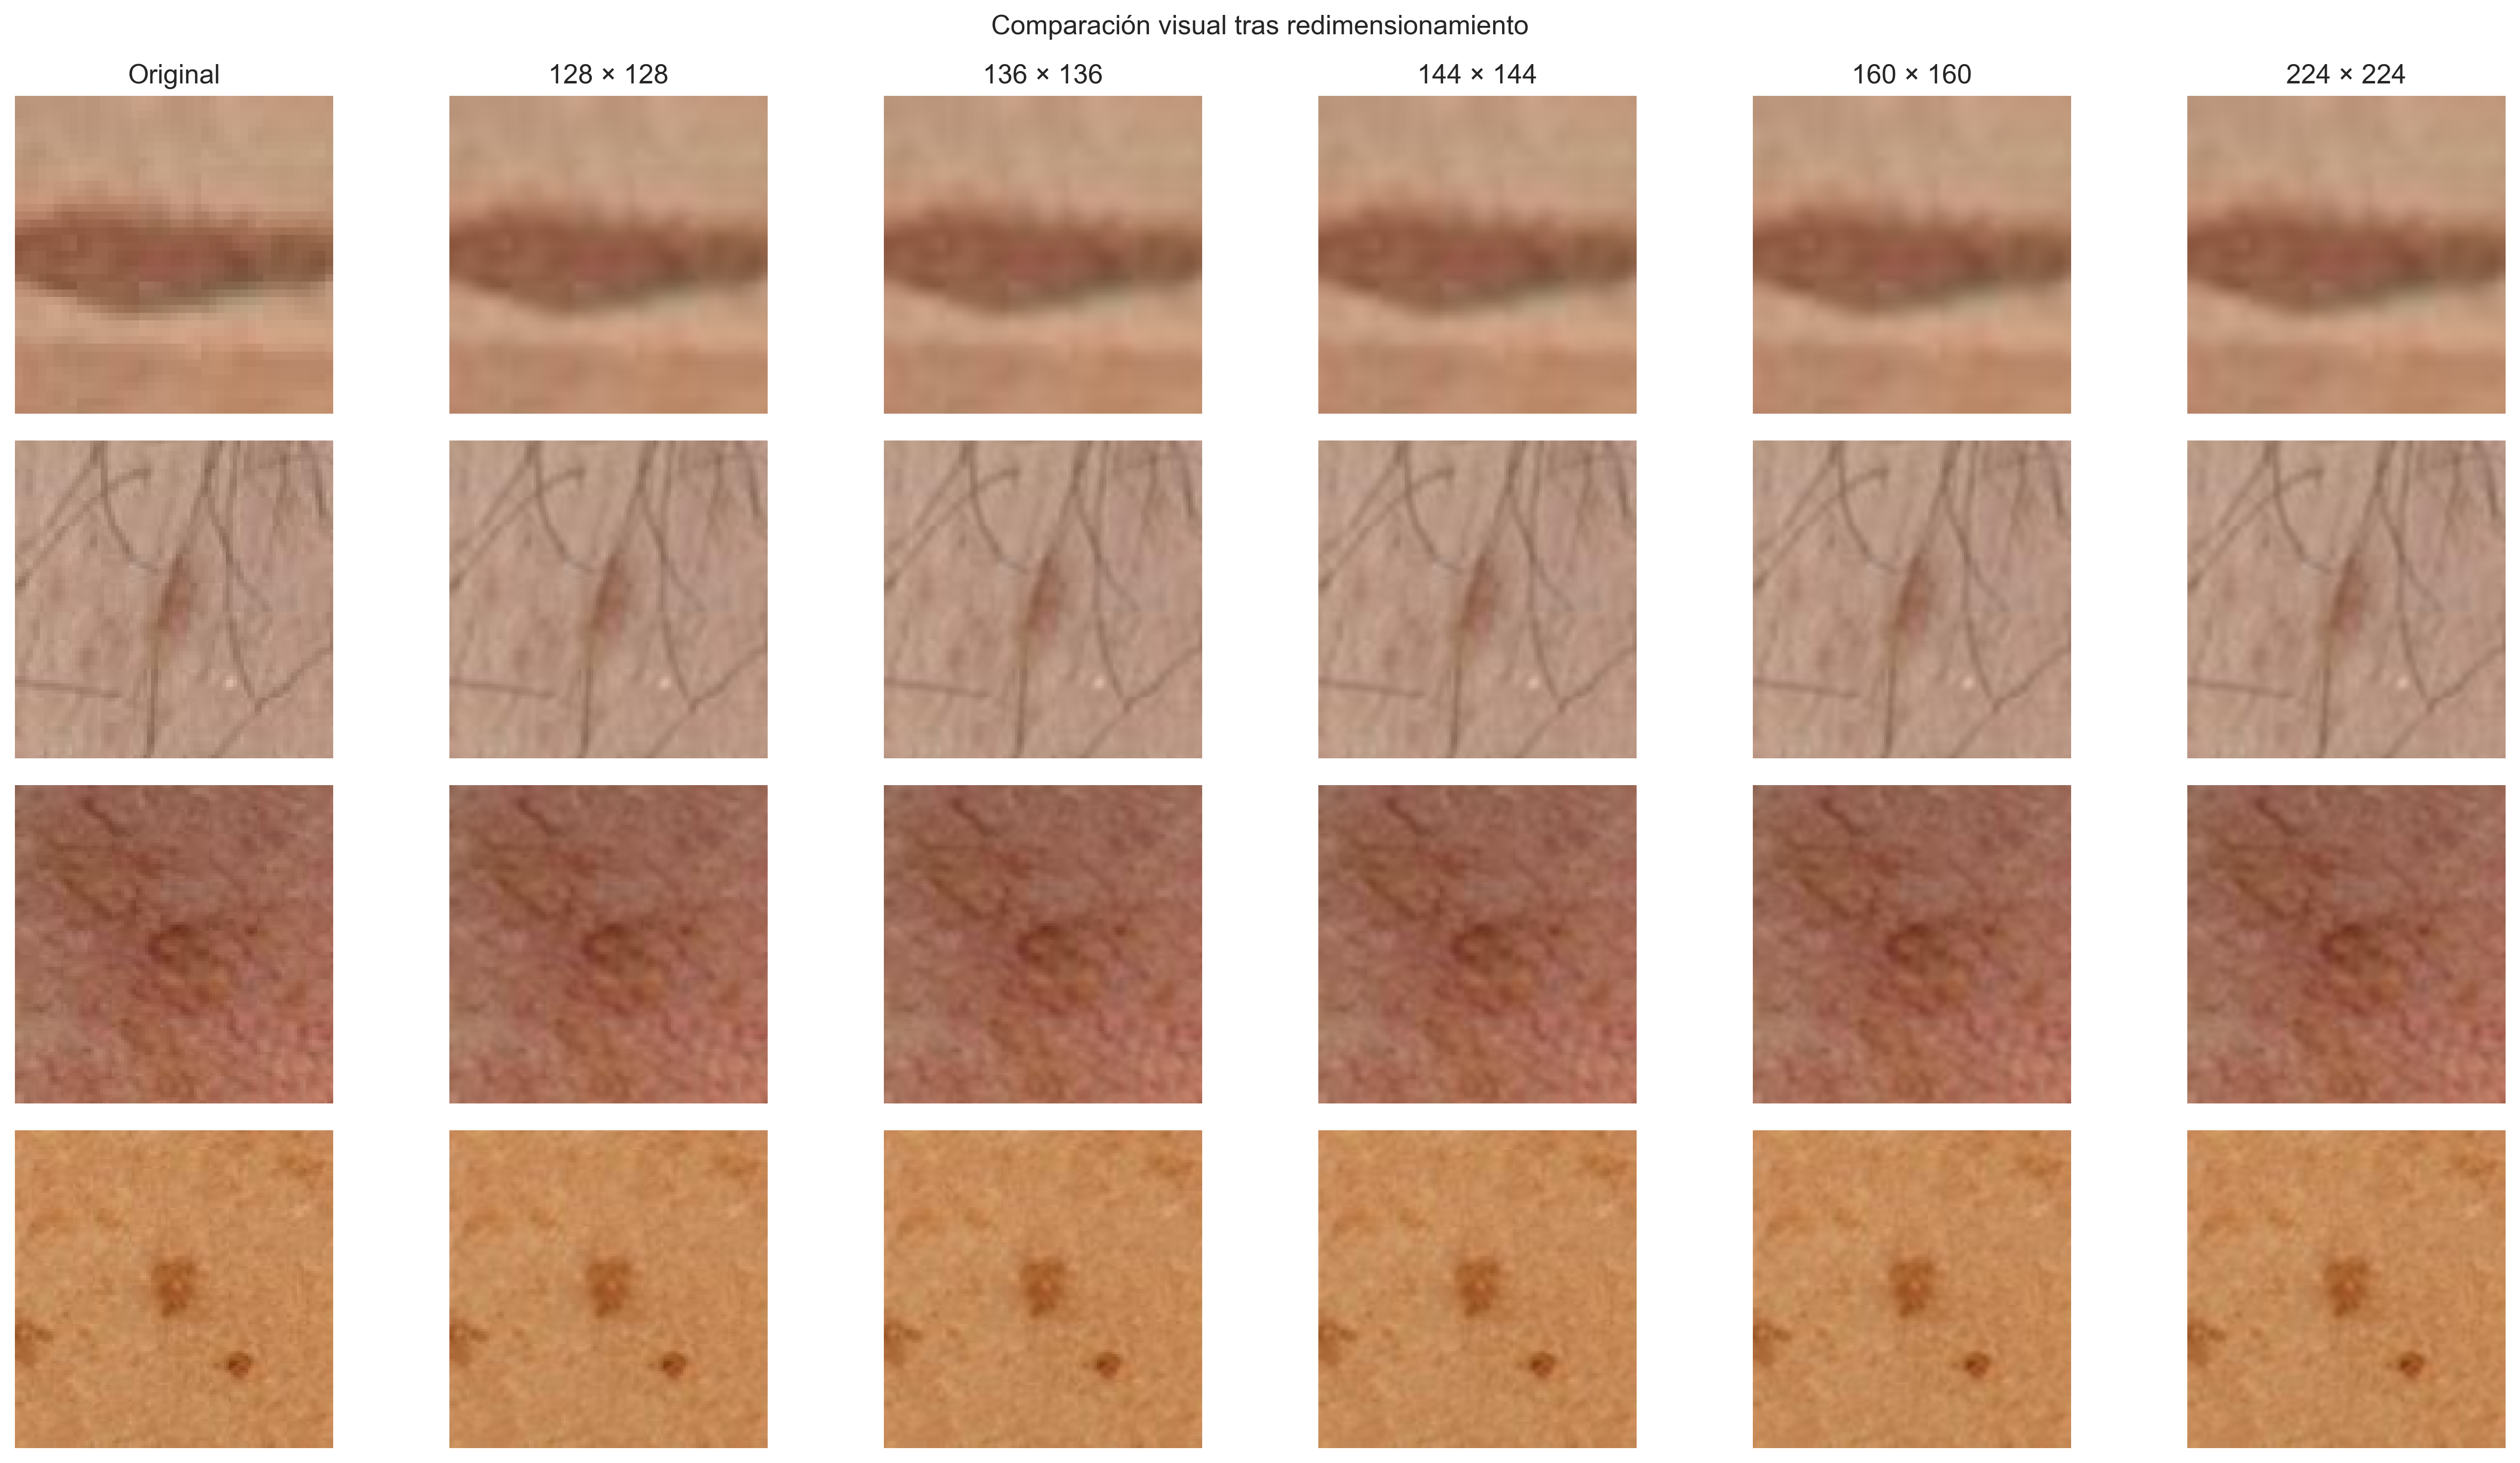

In [86]:
# Visual comparison after resizing representative images

resample_filter = (
    Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
)

comparison_sizes = [128, 136, 144, 160, 224]

fig, axes = plt.subplots(
    len(resize_comparison_df),
    len(comparison_sizes) + 1,
    figsize=(18, 10),
)

for row_idx, (_, row) in enumerate(resize_comparison_df.iterrows()):
    img_path = image_path_map[row["image_id"]]

    with Image.open(img_path) as original:
        original = original.convert("RGB")

        for col_idx in range(len(comparison_sizes) + 1):
            ax = axes[row_idx, col_idx]

            if col_idx == 0:
                display_img = original
                title = "Original"
            else:
                size = comparison_sizes[col_idx - 1]
                display_img = original.resize(
                    (size, size),
                    resample_filter,
                )
                title = f"{size} × {size}"

            ax.imshow(display_img)
            ax.axis("off")

            if row_idx == 0:
                ax.set_title(title)

            if col_idx == 0:
                ax.set_ylabel(
                    f"{row['resolution_group']}\n{int(row['width'])} px",
                    fontsize=EDA_STYLE["label_size"],
                )

plt.suptitle(
    "Comparación visual tras redimensionamiento",
    fontsize=EDA_STYLE["title_size"],
)

figures["resize_visual_comparison"] = fig
plt.tight_layout()
plt.show()

The visual comparison shows that resizing low-resolution and median-resolution images to larger input sizes does not appear to recover additional visual detail. Instead, larger target sizes mainly enlarge the existing image structure through interpolation.

This is especially evident for the minimum-resolution example (41 × 41 px), where all resized versions remain visually blurred. For the P1 and P1–P5 examples, resizing to 128 × 128, 136 × 136 or 144 × 144 produces visually similar results, while larger sizes do not clearly add meaningful information.

The median-resolution example (131 × 131 px) is already close to the main candidate input sizes. Therefore, resizing to 128 × 128, 136 × 136 or 144 × 144 involves only mild transformations.

Overall, this qualitative inspection supports the quantitative analysis: 128 × 128, 136 × 136 and 144 × 144 are reasonable candidates, while 160 × 160 and especially 224 × 224 are less naturally aligned with the native image resolution distribution. Images with very low native resolution should be flagged for inspection, but the visual comparison does not justify automatic exclusion based on resolution alone.

### Provisional Resize Strategy

Based on the native resolution distribution, the resize impact analysis and the upsampling severity assessment, three primary candidate input sizes are retained for further evaluation: 128 × 128, 136 × 136 and 144 × 144.

The 128 × 128 size is the conservative baseline. It is close to the native median resolution and limits unnecessary upsampling, making it the safest option from a preprocessing perspective.

The 136 × 136 size is the most balanced candidate. It lies close to the empirical transition between downsampling and upsampling and may represent a useful compromise between preserving spatial detail and avoiding excessive interpolation.

The 144 × 144 size is retained as a higher-resolution compromise. It requires upsampling for a larger proportion of images, but the median scale factor remains moderate. Therefore, it may be worth evaluating if the additional spatial resolution improves model performance.

The 96 × 96, 160 × 160 and 224 × 224 sizes are retained as reference candidates. The 96 × 96 size represents a lightweight low-resolution baseline, while 160 × 160 provides an upper intermediate reference. The 224 × 224 size is mainly relevant for compatibility with pretrained computer vision architectures, but it is less aligned with the native resolution distribution of this dataset.

No image is excluded solely based on native resolution at this stage. Images requiring extreme upsampling should be flagged for visual inspection and potential sensitivity analyses, especially if one of the larger candidate sizes is selected.

The next step is to evaluate the storage and computational implications of these candidate input sizes before selecting the final preprocessing strategy.

# Storage and Computational Cost Analysis

The previous sections identified several candidate input sizes based on the native image resolution distribution and the expected resizing impact.

This section evaluates the storage and computational implications of these candidates. The goal is to distinguish between three different concepts:

- Current on-disk storage of the original compressed JPG images.
- Approximate computational cost during training, which scales with the number of pixels.
- Estimated storage requirements if resized copies of the dataset were generated.

This distinction is important because compressed image size on disk is not equivalent to memory usage during model training. Once images are loaded and converted into tensors, memory requirements depend mainly on the input size, number of channels, batch size and data type.

### Current Raw Image Storage

First, the current storage size of the raw image dataset was quantified using the original JPG files.

This provides the baseline storage requirement before any resizing or preprocessing strategy is applied.

In [68]:
# Compute current file size for each raw image

file_size_records = []

for img_path in tqdm(image_path_map.values()):
    file_size_records.append(
        {
            "image_id": img_path.stem,
            "file_size_bytes": img_path.stat().st_size,
        }
    )

file_size_df = pd.DataFrame(file_size_records)

file_size_df["file_size_kb"] = file_size_df["file_size_bytes"] / 1024
file_size_df["file_size_mb"] = file_size_df["file_size_bytes"] / 1024**2

file_size_df.head()

  0%|          | 0/401059 [00:00<?, ?it/s]

,image_id,file_size_bytes,file_size_kb,file_size_mb
0,ISIC_9212838,2917,2.848633,0.002782
1,ISIC_7419042,3466,3.384766,0.003305
2,ISIC_4607958,2387,2.331055,0.002276
3,ISIC_2314849,3259,3.182617,0.003108
4,ISIC_1432149,2683,2.620117,0.002559


In [70]:
# Summarize current raw image storage

raw_storage_summary = pd.DataFrame(
    {
        "n_images": [len(file_size_df)],
        "total_size_gb": [file_size_df["file_size_bytes"].sum() / 1024**3],
        "mean_file_size_kb": [file_size_df["file_size_kb"].mean()],
        "median_file_size_kb": [file_size_df["file_size_kb"].median()],
        "min_file_size_kb": [file_size_df["file_size_kb"].min()],
        "p95_file_size_kb": [file_size_df["file_size_kb"].quantile(0.95)],
        "max_file_size_kb": [file_size_df["file_size_kb"].max()],
    }
)

print(raw_storage_summary.round(3))

   n_images  total_size_gb  mean_file_size_kb  median_file_size_kb  \
0    401059          1.059              2.768                2.722   

   min_file_size_kb  p95_file_size_kb  max_file_size_kb  
0             0.818              3.79             7.691  


The raw image dataset contains 401,059 JPG files and occupies approximately 1.06 GB on disk. Individual files are small, with a median size of 2.72 KB and a mean size of 2.77 KB. Most images remain below 3.79 KB, corresponding to the 95th percentile, while the largest file reaches 7.69 KB.

These values reflect the compressed JPG storage size of the original dataset. They should not be interpreted as the memory required during model training, since images are decoded and converted into tensors before being passed to the model.


In [71]:
# Merge file size information with resolution metadata

image_storage_df = resolution_df.merge(
    file_size_df,
    on="image_id",
    how="left",
)

missing_file_sizes = image_storage_df["file_size_bytes"].isna().sum()

print("Images with missing file size:", missing_file_sizes)

image_storage_df.head()

Images with missing file size: 0


,image_id,width,height,aspect_ratio,file_size_bytes,file_size_kb,file_size_mb
0,ISIC_0015670,139,139,1.0,3325,3.247070,0.003171
1,ISIC_0015845,127,127,1.0,2996,2.925781,0.002857
2,ISIC_0015864,145,145,1.0,3566,3.482422,0.003401
3,ISIC_0015902,109,109,1.0,1998,1.951172,0.001905
4,ISIC_0024200,125,125,1.0,2969,2.899414,0.002831


### Native Resolution and File Size

The relationship between native image resolution and compressed file size was inspected.

Although larger images generally contain more pixels, JPG file size also depends on compression level, image complexity, color variation and texture. Therefore, this analysis is descriptive and should not be interpreted as a direct measure of computational cost.

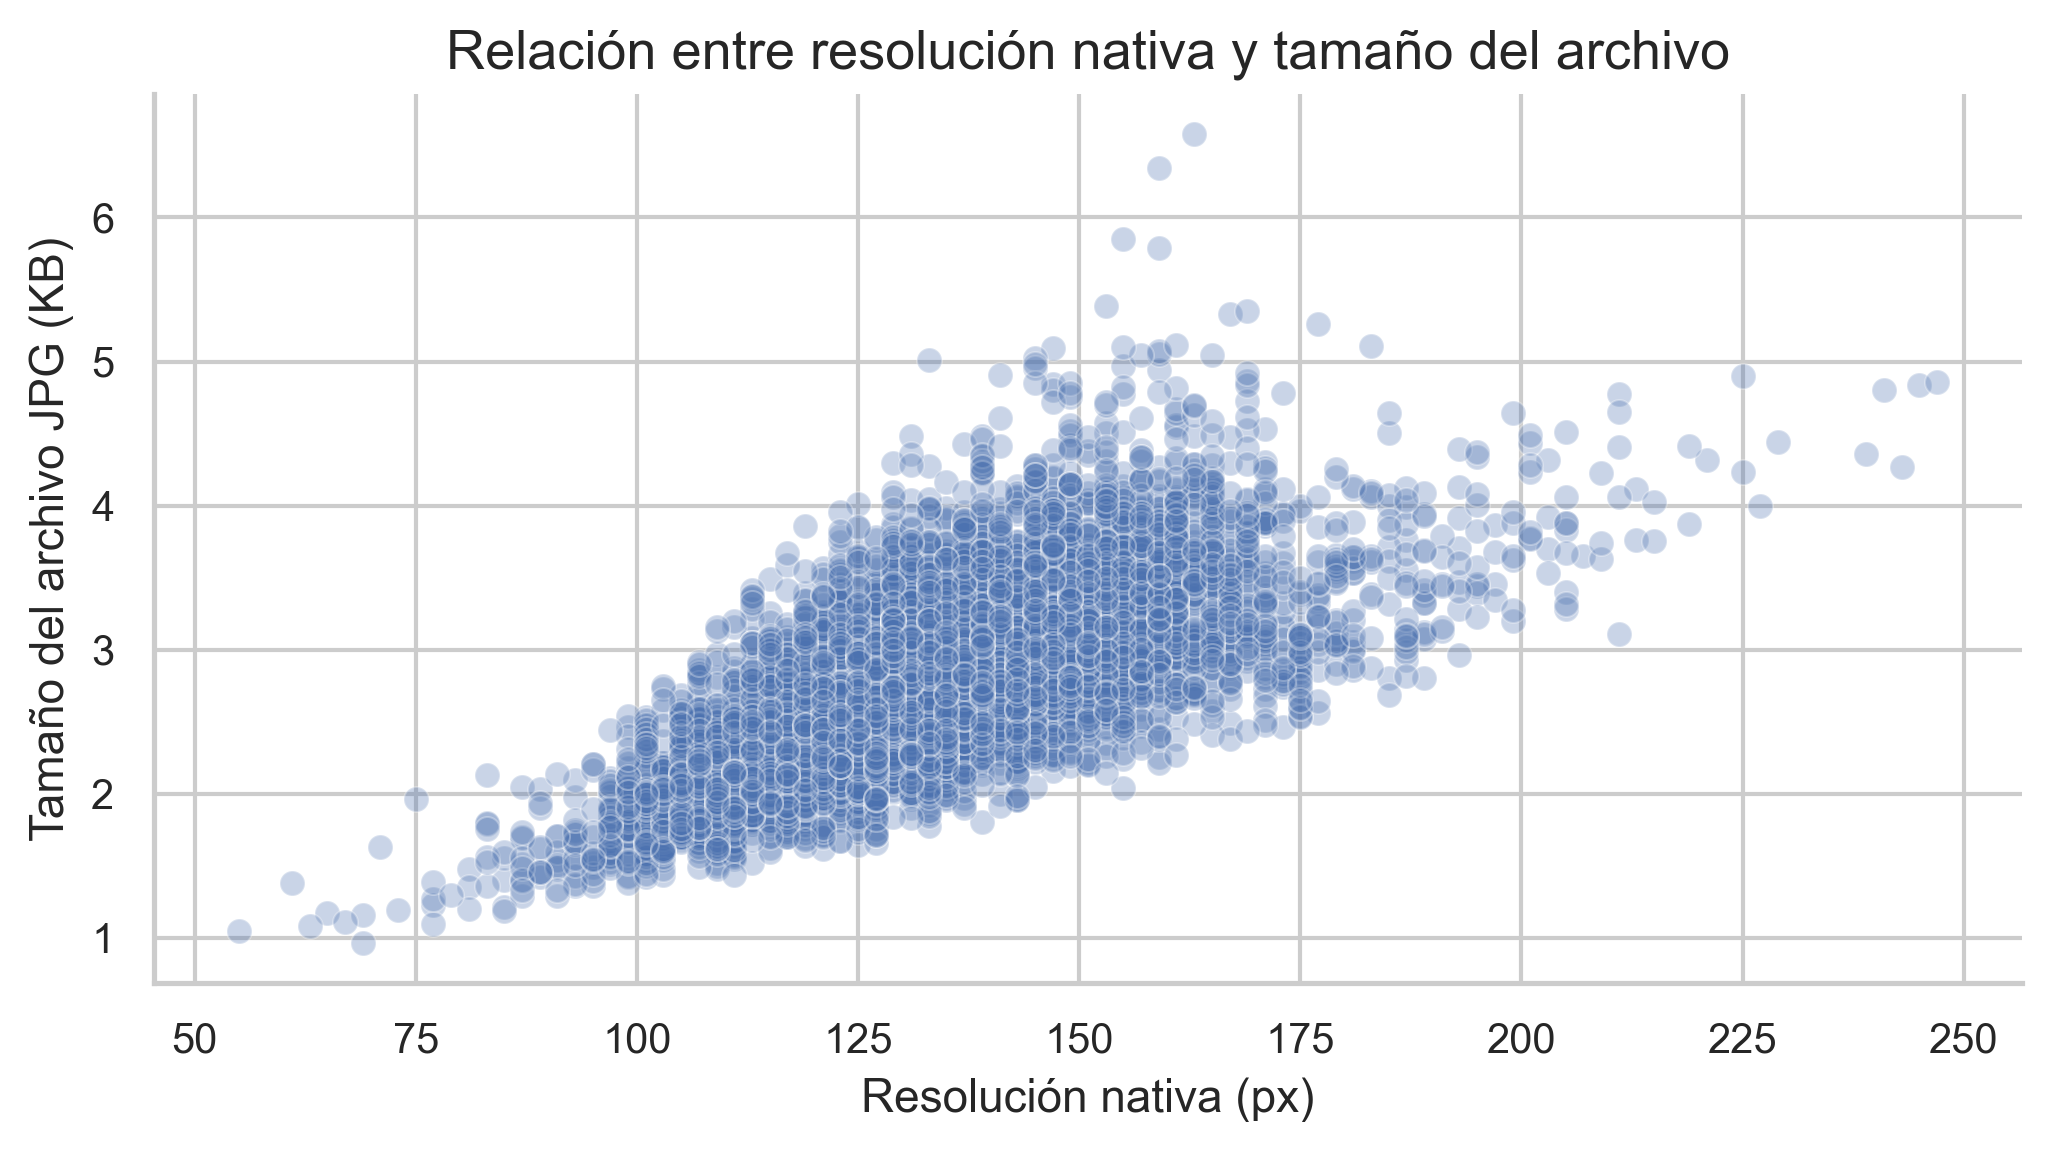

In [72]:
# Plot native resolution versus compressed file size

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.scatterplot(
    data=image_storage_df.sample(
        n=min(10000, len(image_storage_df)),
        random_state=42,
    ),
    x="width",
    y="file_size_kb",
    alpha=0.3,
    ax=ax,
)

clean_axis_labels(
    ax,
    xlabel="Resolución nativa (px)",
    ylabel="Tamaño del archivo JPG (KB)",
    title="Relación entre resolución nativa y tamaño del archivo",
)

plt.tight_layout()
plt.show()

The scatter plot shows a positive association between native image resolution and compressed JPG file size: larger images generally occupy more disk space. However, the relationship is not perfectly linear, as JPG size also depends on image content, texture, colour variation and compression efficiency.

Overall, the current raw dataset is relatively lightweight in terms of disk storage. However, this does not necessarily imply low computational cost during training, because tensor memory and model cost scale mainly with the number of pixels after resizing rather than with the compressed JPG file size.


In [69]:
storage_candidate_sizes = [96, 128, 136, 144, 160, 224]

### Pixel-Based Computational Cost

The computational cost of image models is strongly influenced by the input resolution. For square RGB images, the number of input values per image is proportional to:

input size × input size × 3 channels.

Therefore, increasing the input size has a quadratic effect on the number of pixels and on the approximate memory required per batch.

This section compares candidate input sizes using 128 × 128 as the reference.

In [74]:
# Candidate sizes for storage and computational cost analysis

storage_candidate_sizes = [96, 128, 136, 144, 160, 224]

n_images = len(resolution_df)
reference_size = 128

pixel_cost_summary = []

for size in storage_candidate_sizes:
    pixels_per_image = size * size
    rgb_values_per_image = pixels_per_image * 3

    pixel_cost_summary.append(
        {
            "input_size": size,
            "pixels_per_image": pixels_per_image,
            "relative_pixels_vs_128": pixels_per_image / (reference_size**2),
            "uint8_mb_per_image": rgb_values_per_image * 1 / 1024**2,
            "float32_mb_per_image": rgb_values_per_image * 4 / 1024**2,
            "full_dataset_uint8_gb": rgb_values_per_image * n_images * 1 / 1024**3,
            "full_dataset_float32_gb": rgb_values_per_image * n_images * 4 / 1024**3,
            "batch_32_float32_mb": rgb_values_per_image * 32 * 4 / 1024**2,
            "batch_64_float32_mb": rgb_values_per_image * 64 * 4 / 1024**2,
        }
    )

pixel_cost_df = pd.DataFrame(pixel_cost_summary)

print(pixel_cost_df.round(3))

   input_size  pixels_per_image  relative_pixels_vs_128  uint8_mb_per_image  \
0          96              9216                   0.562               0.026   
1         128             16384                   1.000               0.047   
2         136             18496                   1.129               0.053   
3         144             20736                   1.266               0.059   
4         160             25600                   1.562               0.073   
5         224             50176                   3.062               0.144   

   float32_mb_per_image  full_dataset_uint8_gb  full_dataset_float32_gb  \
0                 0.105                 10.327                   41.308   
1                 0.188                 18.359                   73.436   
2                 0.212                 20.726                   82.902   
3                 0.237                 23.236                   92.943   
4                 0.293                 28.686                  114.744

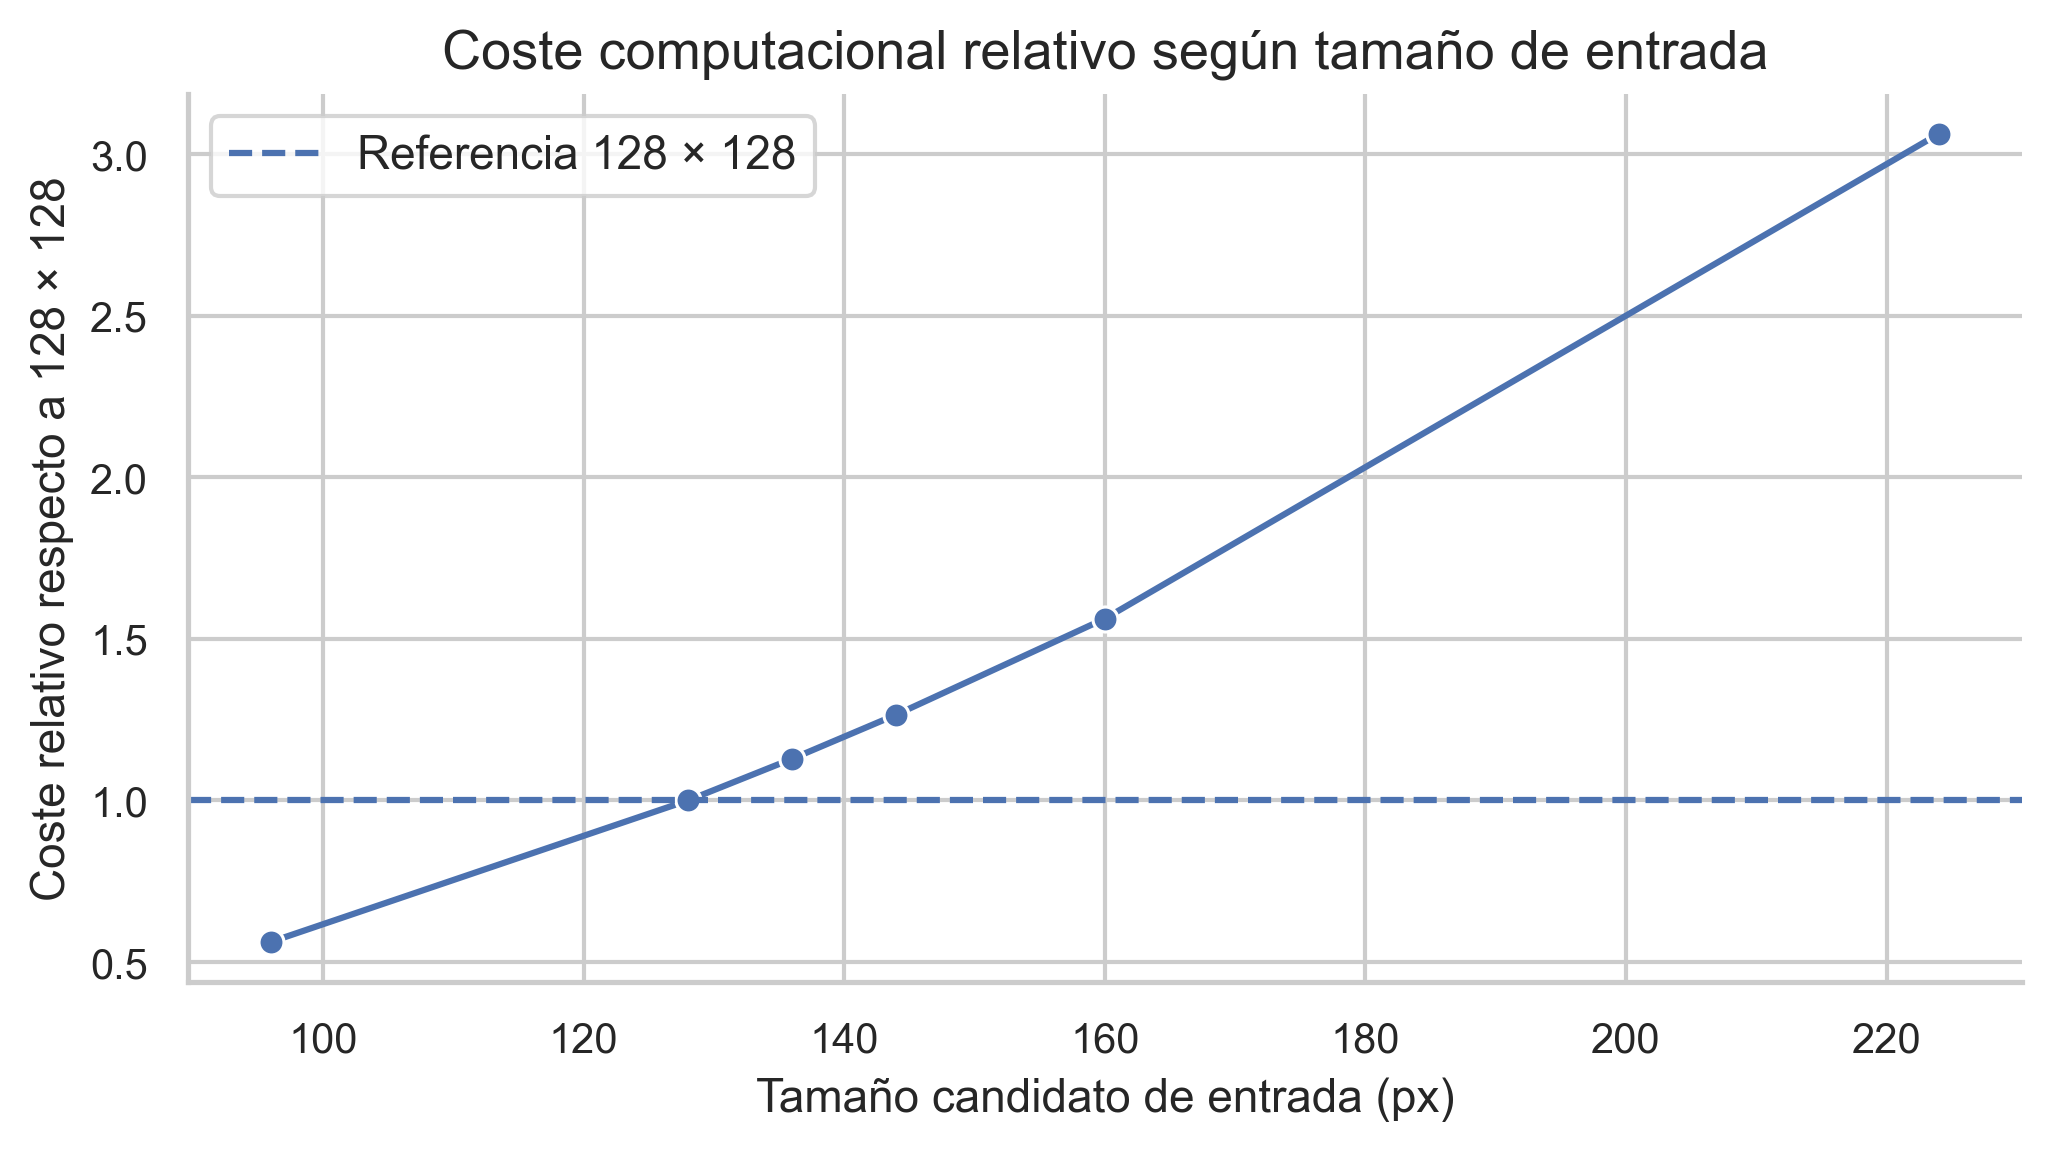

In [91]:
# Plot relative computational cost by candidate input size

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.lineplot(
    data=pixel_cost_df,
    x="input_size",
    y="relative_pixels_vs_128",
    marker="o",
    ax=ax,
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Referencia 128 × 128",
)

clean_axis_labels(
    ax,
    xlabel="Tamaño candidato de entrada (px)",
    ylabel="Coste relativo respecto a 128 × 128",
    title="Coste computacional relativo según tamaño de entrada",
)

ax.legend()

figures["relative_computational_cost"] = fig
plt.tight_layout()
plt.show()

The pixel-based cost analysis confirms that computational cost increases quadratically with input size.

Using 128 × 128 as the reference, 96 × 96 would require only 56.2% of the pixels, making it the most computationally efficient option. However, this reduction may discard potentially useful spatial detail.

The main candidate sizes show a moderate increase in pixel count. Compared with 128 × 128, 136 × 136 requires 1.13× more pixels and 144 × 144 requires 1.27× more pixels. These increases are relatively limited and may be acceptable if they lead to improved model performance.

The 160 × 160 option increases the pixel count to 1.56× the 128 × 128 baseline, representing a more noticeable increase in computational cost. The 224 × 224 option is substantially more expensive, requiring 3.06× more pixels than 128 × 128.

The estimated tensor sizes also highlight the difference between compressed image storage and training memory. Although the raw JPG dataset occupies only around 1 GB on disk, decoded image tensors would require substantially more memory. These full-dataset tensor estimates are theoretical, since training is performed in batches, but they illustrate why input size directly affects memory usage, training speed and feasible batch size.

Overall, 128 × 128 remains the conservative computational baseline, while 136 × 136 and 144 × 144 appear to be reasonable intermediate candidates. The 160 × 160 size should be treated as a higher-cost reference, and 224 × 224 should mainly be considered if required for pretrained model compatibility.

### Estimated Storage of Resized JPG Copies

If resized copies of the dataset are generated and saved to disk, storage requirements will depend on the target size and JPG compression settings.

To estimate this cost without processing the full dataset, a random sample of images was resized to each candidate input size and temporarily encoded as JPG in memory. The average compressed file size was then extrapolated to the full dataset.

This provides an approximate storage estimate for each candidate size. The result should be interpreted as an estimate, not an exact value, because JPG size depends on image content and compression settings.

In [78]:
# Estimate storage of resized JPG copies using a random sample

sample_n = min(2000, len(resolution_df))
jpeg_quality = 95

resize_storage_sample_df = resolution_df.sample(
    n=sample_n,
    random_state=42,
).copy()

resample_filter = (
    Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
)

resized_storage_records = []

for _, row in tqdm(
    resize_storage_sample_df.iterrows(), total=len(resize_storage_sample_df)
):
    img_path = image_path_map[row["image_id"]]

    with Image.open(img_path) as img:
        img = img.convert("RGB")

        for size in storage_candidate_sizes:
            resized_img = img.resize(
                (size, size),
                resample_filter,
            )

            buffer = BytesIO()
            resized_img.save(
                buffer,
                format="JPEG",
                quality=jpeg_quality,
                optimize=True,
            )

            resized_storage_records.append(
                {
                    "image_id": row["image_id"],
                    "input_size": size,
                    "estimated_jpg_size_bytes": buffer.tell(),
                }
            )

resized_storage_sample_results_df = pd.DataFrame(resized_storage_records)

resized_storage_sample_results_df.head()

  0%|          | 0/2000 [00:00<?, ?it/s]

,image_id,input_size,estimated_jpg_size_bytes
0,ISIC_6973879,96,2506
1,ISIC_6973879,128,3845
2,ISIC_6973879,136,4300
3,ISIC_6973879,144,4556
4,ISIC_6973879,160,5276


In [79]:
# Summarize estimated resized JPG storage

resized_storage_summary = (
    resized_storage_sample_results_df.groupby("input_size")["estimated_jpg_size_bytes"]
    .agg(["mean", "median", "min", "max"])
    .reset_index()
)

resized_storage_summary["estimated_total_size_gb"] = (
    resized_storage_summary["mean"] * len(resolution_df) / 1024**3
)

resized_storage_summary["estimated_total_size_relative_to_128"] = (
    resized_storage_summary["estimated_total_size_gb"]
    / resized_storage_summary.loc[
        resized_storage_summary["input_size"] == 128,
        "estimated_total_size_gb",
    ].iloc[0]
)

print(resized_storage_summary.round(3))

   input_size       mean   median   min    max  estimated_total_size_gb  \
0          96   3027.979   3007.5  1914   4798                    1.131   
1         128   4628.797   4579.5  2713   7539                    1.729   
2         136   5127.505   5074.0  3087   8333                    1.915   
3         144   5499.836   5450.0  3247   8806                    2.054   
4         160   6390.122   6350.5  3780  10354                    2.387   
5         224  10158.348  10074.0  5968  16542                    3.794   

   estimated_total_size_relative_to_128  
0                                 0.654  
1                                 1.000  
2                                 1.108  
3                                 1.188  
4                                 1.381  
5                                 2.195  


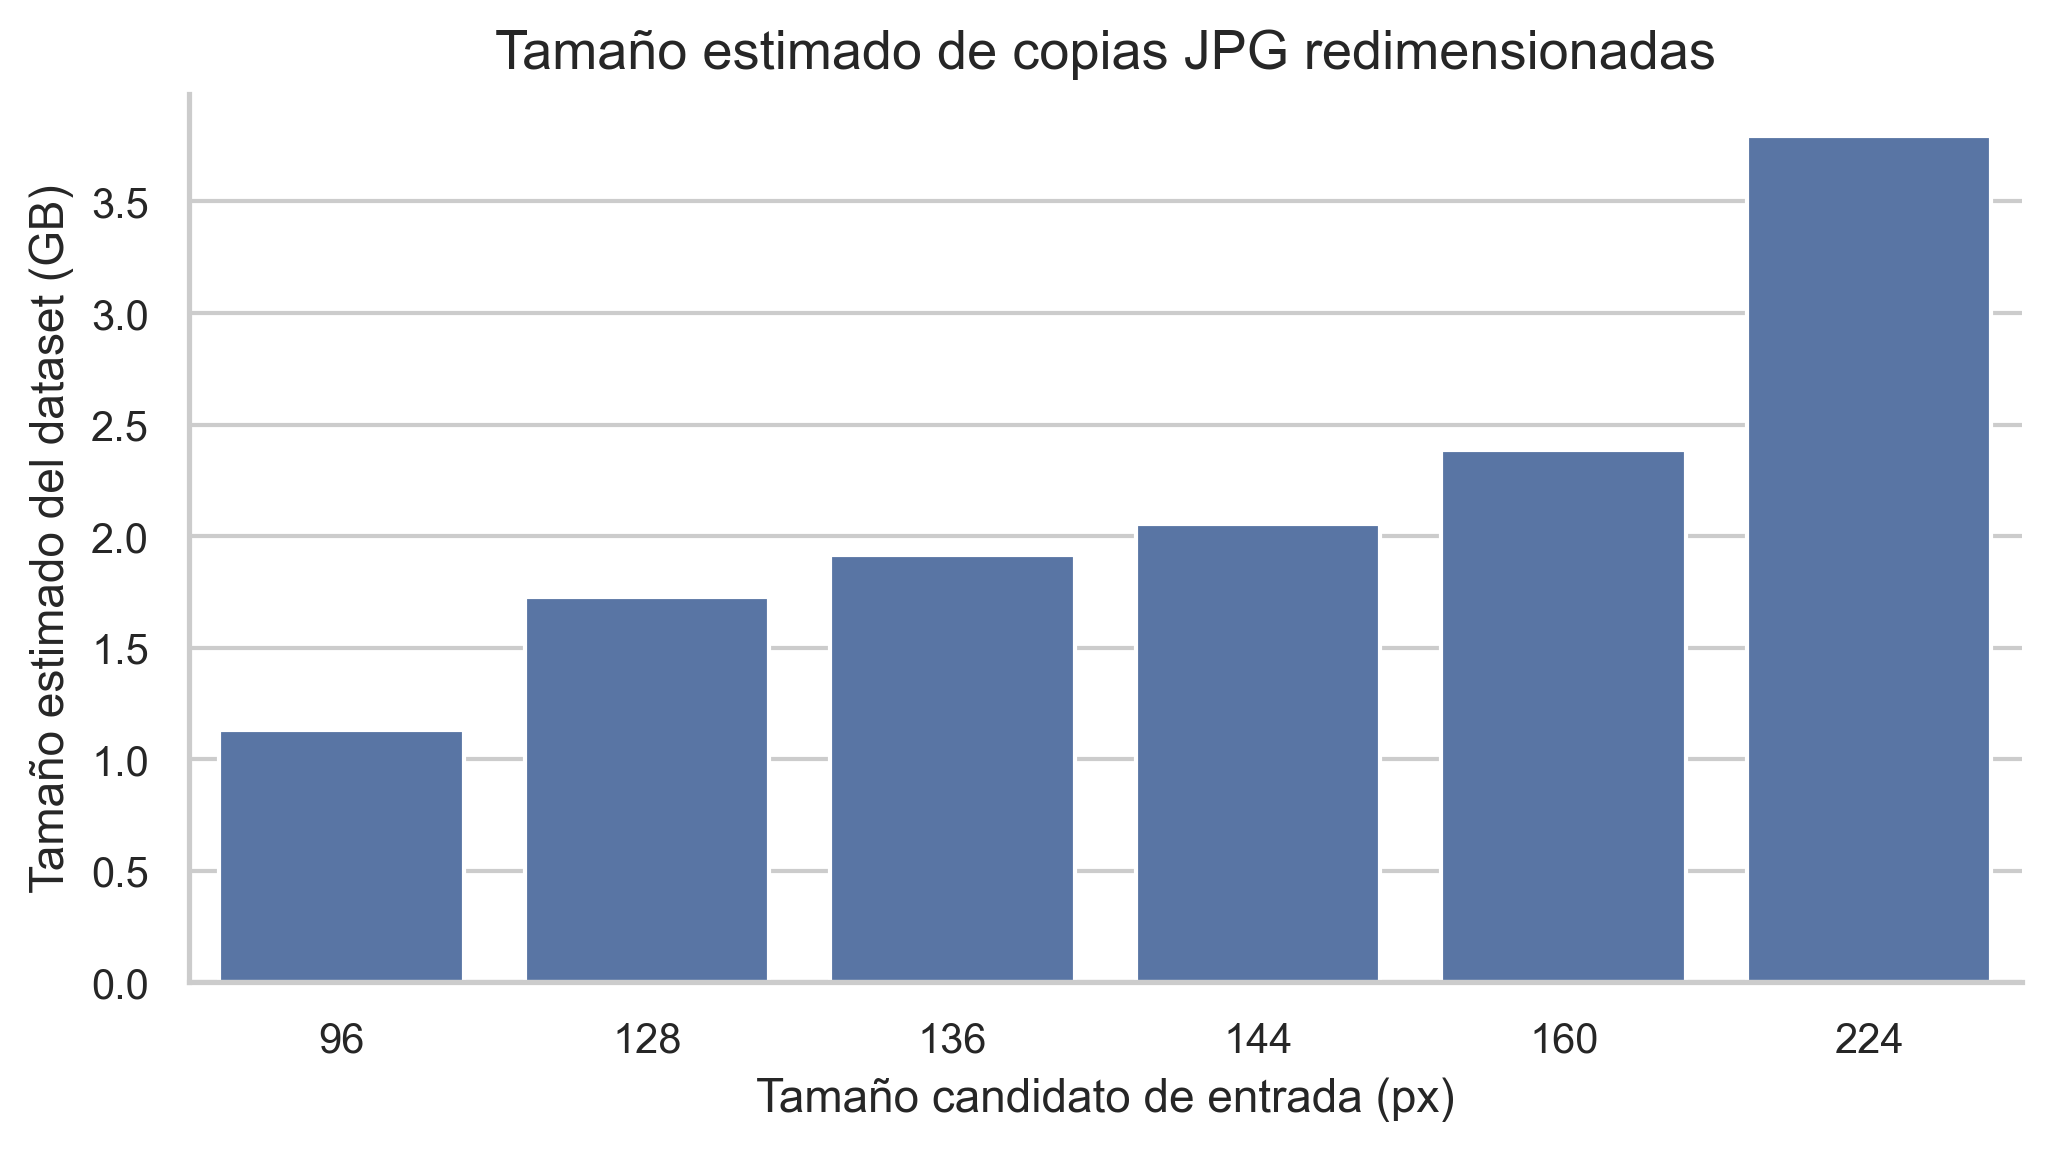

In [80]:
# Plot estimated storage of resized JPG copies

fig, ax = plt.subplots(figsize=EDA_STYLE["figure_size"])

sns.barplot(
    data=resized_storage_summary,
    x="input_size",
    y="estimated_total_size_gb",
    ax=ax,
)

clean_axis_labels(
    ax,
    xlabel="Tamaño candidato de entrada (px)",
    ylabel="Tamaño estimado del dataset (GB)",
    title="Tamaño estimado de copias JPG redimensionadas",
)

plt.tight_layout()
plt.show()

The estimated storage analysis shows that saving resized JPG copies of the dataset would remain feasible for all candidate sizes, but storage requirements increase with input resolution.

At 128 × 128, the estimated resized dataset size is approximately 1.73 GB. The 136 × 136 and 144 × 144 candidates would require approximately 1.92 GB and 2.05 GB, respectively, corresponding to moderate increases over the 128 × 128 baseline. This suggests that these intermediate candidates are not problematic from a storage perspective.

The 160 × 160 option would increase the estimated storage requirement to 2.39 GB, while 224 × 224 would require approximately 3.79 GB, more than twice the estimated storage of 128 × 128. Therefore, the main drawback of larger image sizes is not only disk storage, but also the increased pixel count and expected computational cost during training.

These estimates are based on resized JPG copies generated from a sample of images and should be interpreted as approximate. Actual storage may vary depending on compression settings, image content and preprocessing choices.


### Combined Candidate Size Summary

The previous analyses were combined into a single summary table to compare candidate input sizes across three dimensions:

- Resizing behaviour and upsampling severity.
- Pixel-based computational cost.
- Estimated storage if resized JPG copies are generated.

This table supports the final selection of candidate sizes for model development.

In [82]:
# Combine resize severity, pixel cost and estimated storage summaries

combined_candidate_summary = upsampling_severity_df.merge(
    pixel_cost_df,
    on="input_size",
    how="left",
).merge(
    resized_storage_summary[
        [
            "input_size",
            "estimated_total_size_gb",
            "estimated_total_size_relative_to_128",
        ]
    ],
    on="input_size",
    how="left",
)

combined_candidate_summary = combined_candidate_summary[
    [
        "input_size",
        "candidate_type",
        "any_upsampling_pct",
        "upsampling_gt_1_5x_pct",
        "upsampling_gt_2x_pct",
        "relative_pixels_vs_128",
        "estimated_total_size_gb",
        "estimated_total_size_relative_to_128",
        "batch_32_float32_mb",
        "batch_64_float32_mb",
    ]
]

print(combined_candidate_summary.round(3))

   input_size candidate_type  any_upsampling_pct  upsampling_gt_1_5x_pct  \
0         128        primary              40.092                   0.268   
1         136        primary              60.712                   0.417   
2         144        primary              76.532                   0.884   
3          96      reference               0.884                   0.021   
4         160      reference              92.869                   4.318   
5         224      reference              99.927                  83.839   

   upsampling_gt_2x_pct  relative_pixels_vs_128  estimated_total_size_gb  \
0                 0.021                   1.000                    1.729   
1                 0.037                   1.129                    1.915   
2                 0.061                   1.266                    2.054   
3                 0.001                   0.562                    1.131   
4                 0.143                   1.562                    2.387   
5          

The combined candidate-size summary integrates resizing behaviour, upsampling severity, estimated storage requirements and pixel-based computational cost.

Among the primary candidates, 128 × 128 remains the most conservative option. It has the lowest computational and storage cost within the main candidate group, with an estimated resized dataset size of 1.73 GB and no relevant extreme upsampling burden. Although 40.09% of images require upsampling, only 0.27% require >1.5× upsampling and 0.02% require >2× upsampling.

The 136 × 136 candidate provides a slightly higher input resolution while maintaining a moderate cost increase. Compared with 128 × 128, it requires 1.13× more pixels and an estimated 1.92 GB of resized JPG storage. Severe upsampling remains very limited, with 0.42% of images requiring >1.5× upsampling and 0.04% requiring >2× upsampling.

The 144 × 144 candidate represents a higher-resolution compromise. It increases the pixel count to 1.27× relative to 128 × 128 and the estimated resized dataset size to 2.05 GB. Although 76.53% of images would require some upsampling, severe upsampling remains uncommon, affecting 0.88% of images at >1.5× and only 0.06% at >2×. Therefore, 144 × 144 remains feasible if the additional spatial resolution improves model performance.

The 96 × 96 reference size is the most efficient option, requiring only 56.2% of the pixels of 128 × 128 and an estimated storage size of 1.13 GB. However, it is likely to discard spatial detail and should mainly be considered as a lightweight baseline.

The 160 × 160 reference size increases the pixel count to 1.56× and the estimated storage size to 2.39 GB. It remains technically feasible, but it is less conservative because 92.87% of images require upsampling and 4.32% require >1.5× upsampling.

The 224 × 224 size is clearly the most expensive option. It requires 3.06× more pixels than 128 × 128 and an estimated 3.79 GB of resized JPG storage. More importantly, 83.84% of images require >1.5× upsampling and 10.13% require >2× upsampling. Therefore, 224 × 224 is poorly aligned with the native resolution distribution and should only be considered if required by a specific pretrained architecture.

Overall, the most reasonable candidates to carry forward are 128 × 128, 136 × 136 and 144 × 144. The 128 × 128 size should be treated as the conservative baseline, 136 × 136 as the most balanced option, and 144 × 144 as a higher-resolution alternative. No image should be excluded solely based on native resolution or upsampling requirements at this stage, although images requiring >2× upsampling should remain flagged for visual inspection and possible sensitivity analyses.


# FINAL SUMMARY

En este notebook se ha realizado un análisis exploratorio inicial de las imágenes crudas del proyecto, con el objetivo de definir una estrategia razonable de preprocesamiento antes de entrenar modelos de deep learning. A diferencia del EDA de metadatos, aquí el foco no está en variables clínicas o demográficas, sino en la estructura física de las imágenes, su resolución nativa, su calidad técnica, el impacto del redimensionamiento y el coste computacional asociado a distintos tamaños de entrada.

Desde el punto de vista del modelado, cada imagen debe transformarse en una representación numérica homogénea. En la práctica, esto implica convertir cada imagen en un tensor de dimensiones `H × W × 3`, donde `H` y `W` corresponden al tamaño de entrada seleccionado y los 3 canales corresponden a la representación RGB. Los valores originales de los píxeles están almacenados como valores discretos de 8 bits (`0–255`), pero durante el entrenamiento se convierten habitualmente a `float32` y se normalizan, por ejemplo reescalando los valores a `[0, 1]` o aplicando una normalización por media y desviación estándar. Por tanto, las imágenes pasan a ser un conjunto estructurado de variables numéricas, manteniendo su organización espacial para que pueda ser explotada por modelos convolucionales o arquitecturas equivalentes.

## Integridad y estructura del dataset de imágenes

El primer bloque del análisis evaluó la consistencia entre los metadatos y los archivos físicos disponibles en disco. El dataset contiene **401,059 imágenes**, exactamente el mismo número de registros que aparecen en los ficheros de metadatos. No se identificaron imágenes ausentes, imágenes huérfanas ni duplicidades relevantes entre el repositorio físico y la información tabular.

| Aspecto evaluado             |      Resultado | Interpretación                              |
| ---------------------------- | -------------: | ------------------------------------------- |
| Registros en metadatos       |        401,059 | Coinciden con el número de imágenes físicas |
| Imágenes físicas             |        401,059 | Dataset completo en disco                   |
| Imágenes ausentes en disco   |              0 | No requiere exclusión por falta de archivo  |
| Imágenes extra sin metadatos |              0 | No hay archivos huérfanos                   |
| Extensión de archivo         | `.jpg` en 100% | Formato homogéneo                           |
| Modo de color                |    RGB en 100% | Representación homogénea de 3 canales       |
| Imágenes corruptas           |              0 | No requiere reparación ni eliminación       |
| Relación de aspecto          |    1.0 en 100% | Todas las imágenes son cuadradas            |

Tabla XX. Auditoría de integridad, formato y calidad técnica básica de las imágenes crudas.

Estos resultados indican que el dataset de imágenes es técnicamente consistente. No es necesario aplicar pasos adicionales de recuperación de archivos, eliminación de imágenes corruptas, conversión de modos de color ni corrección de relaciones de aspecto. El principal preprocesamiento necesario será, por tanto, el redimensionamiento a un tamaño común de entrada y la posterior conversión a tensores numéricos normalizados.

## Distribución de la resolución nativa

Todas las imágenes son cuadradas, por lo que la anchura (width) y la altura (height) contienen la misma información. Por este motivo, la resolución nativa de cada imagen puede resumirse mediante una única variable numérica: width. Aunque esta variable está registrada en píxeles enteros, en el análisis exploratorio se trata como una variable cuantitativa continua, ya que representa el tamaño espacial original de la imagen.

La distribución de width muestra una concentración principal alrededor de 120–145 px, con una mediana de 131 px y un rango completo entre 41 px y 269 px. La media muestral es 133.25 px, ligeramente superior a la mediana, y la asimetría muestral es positiva (skewness = 0.743), lo que indica una cola derecha moderada formada por un subconjunto reducido de imágenes de mayor resolución. La desviación estándar muestral es 18.27 px, por lo que la mayoría de las imágenes se sitúan relativamente cerca de la zona central de la distribución. El rango intercuartílico se encuentra entre 121 px y 143 px, confirmando que el núcleo principal del dataset está concentrado en resoluciones bajas-moderadas y bastante homogéneas. La curtosis muestral positiva (kurtosis = 2.053) sugiere además una distribución relativamente concentrada alrededor del centro, pero con colas algo más marcadas que una distribución normal.

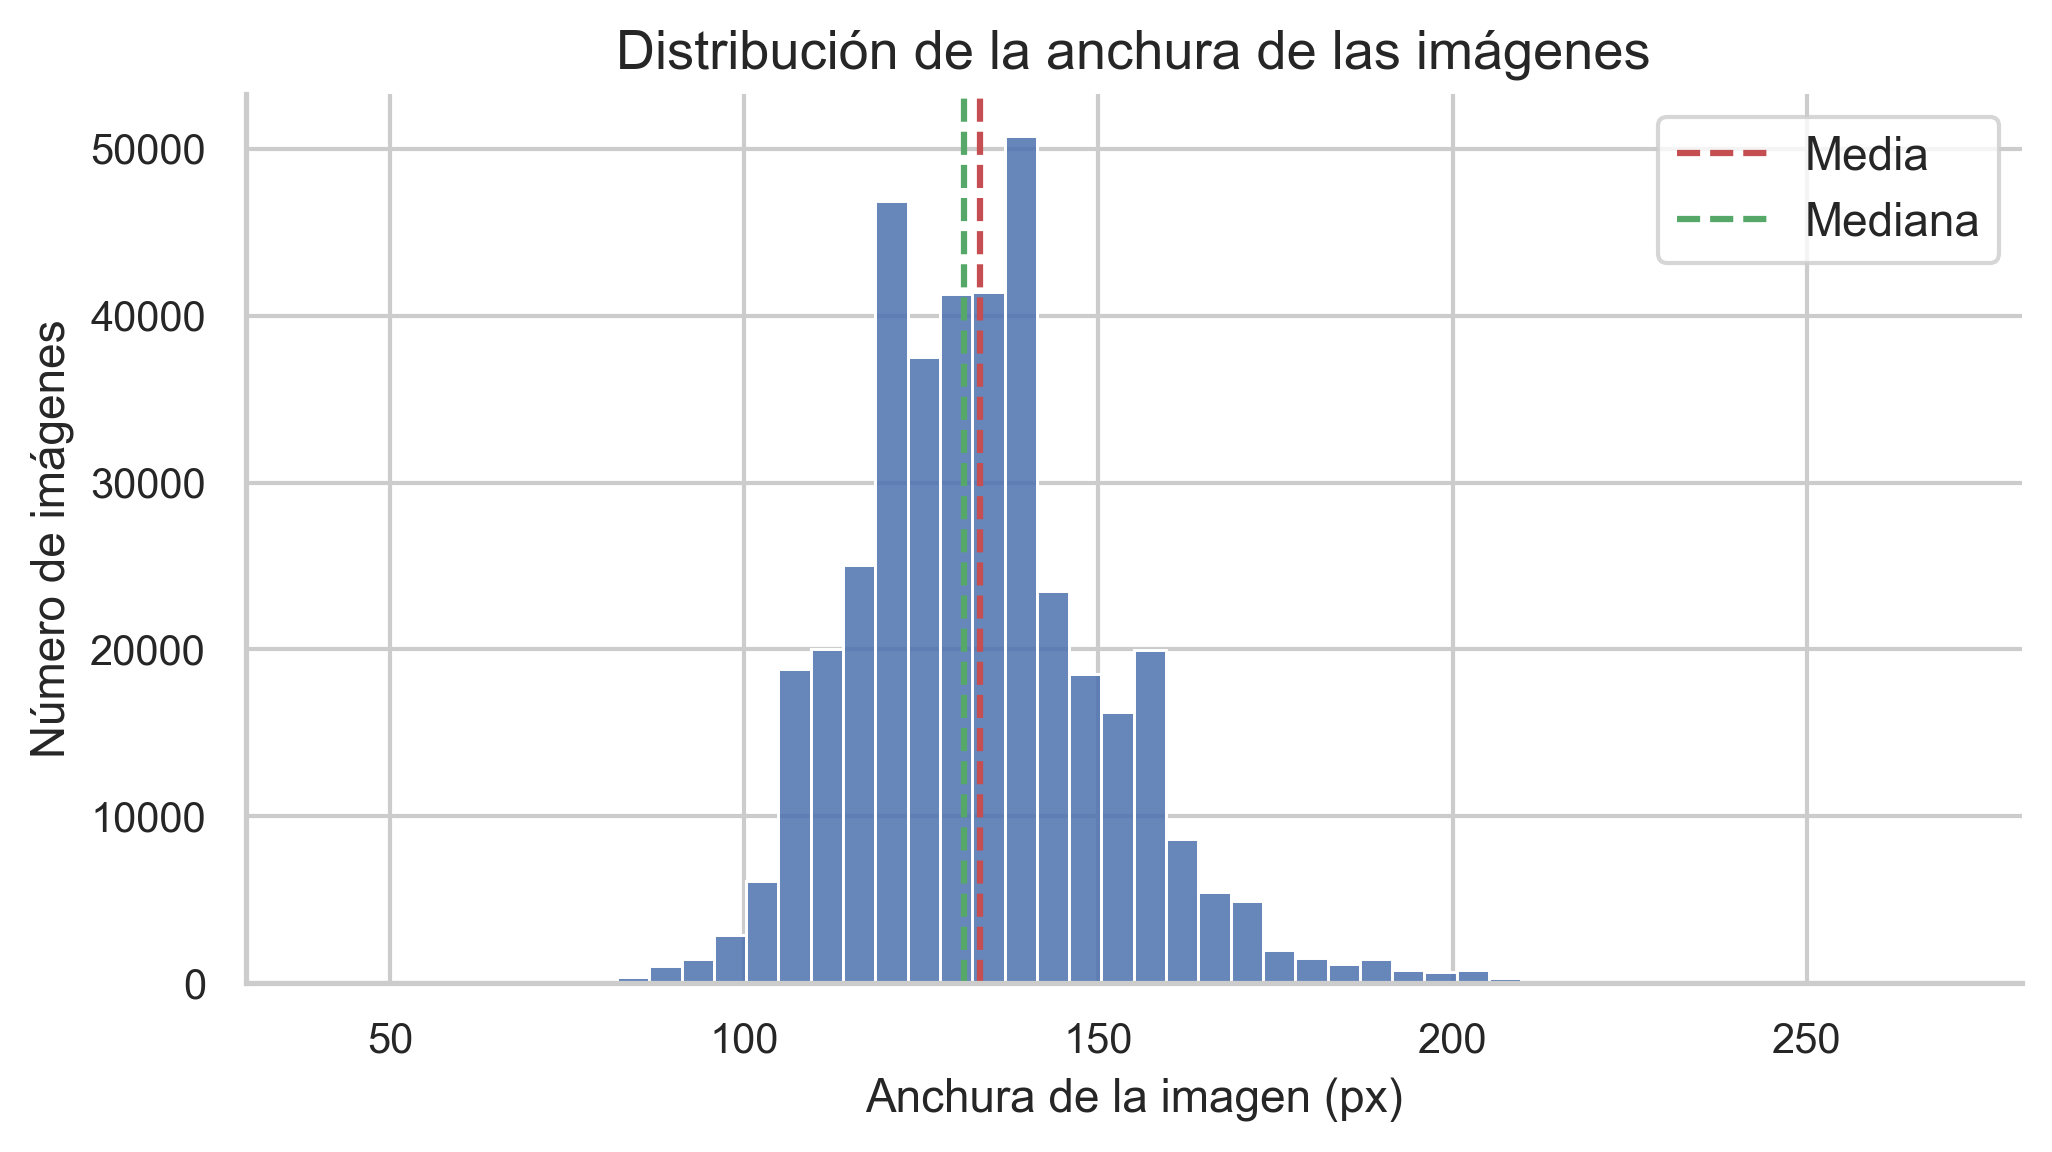

In [85]:
figures["image_resolution_distribution"]

Figura XX. Histograma de la distribución de la anchura nativa (width) de las imágenes (px). Dado que todas las imágenes son cuadradas, width resume directamente la resolución espacial original.

Aunque existen imágenes con resoluciones bajas, estas representan una proporción reducida del dataset. El percentil 1 corresponde a imágenes con resolución nativa menor o igual a **97 px**, mientras que el percentil 5 corresponde a imágenes de hasta **107 px**. En el extremo superior, el percentil 95 corresponde a imágenes de al menos **163 px** y el percentil 99 a imágenes de al menos **189 px**.

| Cola de la distribución | Percentil | Criterio | Imágenes (n) | Imágenes (%) |
| ----------------------- | --------: | -------- | -----------: | -----------: |
| Inferior                |        P1 | ≤ 97 px  |        4,695 |         1.17 |
| Inferior                |        P5 | ≤ 107 px |       23,579 |         5.88 |
| Superior                |       P95 | ≥ 163 px |       23,869 |         5.95 |
| Superior                |       P99 | ≥ 189 px |        4,438 |         1.11 |

Tabla XX. Umbrales percentílicos de resolución nativa.

Desde un punto de vista práctico, las imágenes de baja resolución son las más relevantes para la estrategia de preprocesamiento, ya que requerirán upsampling si se redimensionan a tamaños superiores. Sin embargo, incluso usando umbrales absolutos exigentes, el número de imágenes potencialmente problemáticas es limitado: solo **572 imágenes** están por debajo de 80 px, **1,671** por debajo de 90 px y **6,416** por debajo de 100 px.

| Umbral de baja resolución | Imágenes por debajo del umbral | Porcentaje |
| ------------------------: | -----------------------------: | ---------: |
|                   < 80 px |                            572 |       0.14 |
|                   < 90 px |                          1,671 |       0.42 |
|                  < 100 px |                          6,416 |       1.60 |
|                  < 107 px |                         17,318 |       4.32 |
|                  < 120 px |                         90,696 |      22.61 |
|                  < 128 px |                        160,794 |      40.09 |

Tabla XX. Número de imágenes por debajo de distintos umbrales absolutos de resolución nativa.

Estos umbrales no deben interpretarse como criterios automáticos de exclusión. En particular, los umbrales cercanos a 120–128 px reflejan sobre todo la proporción de imágenes que requerirían cierto grado de upsampling al usar tamaños de entrada próximos a la mediana del dataset. En cambio, umbrales más bajos, como 80, 90 o 100 px, son más útiles para identificar imágenes que conviene marcar para inspección visual o análisis de sensibilidad.

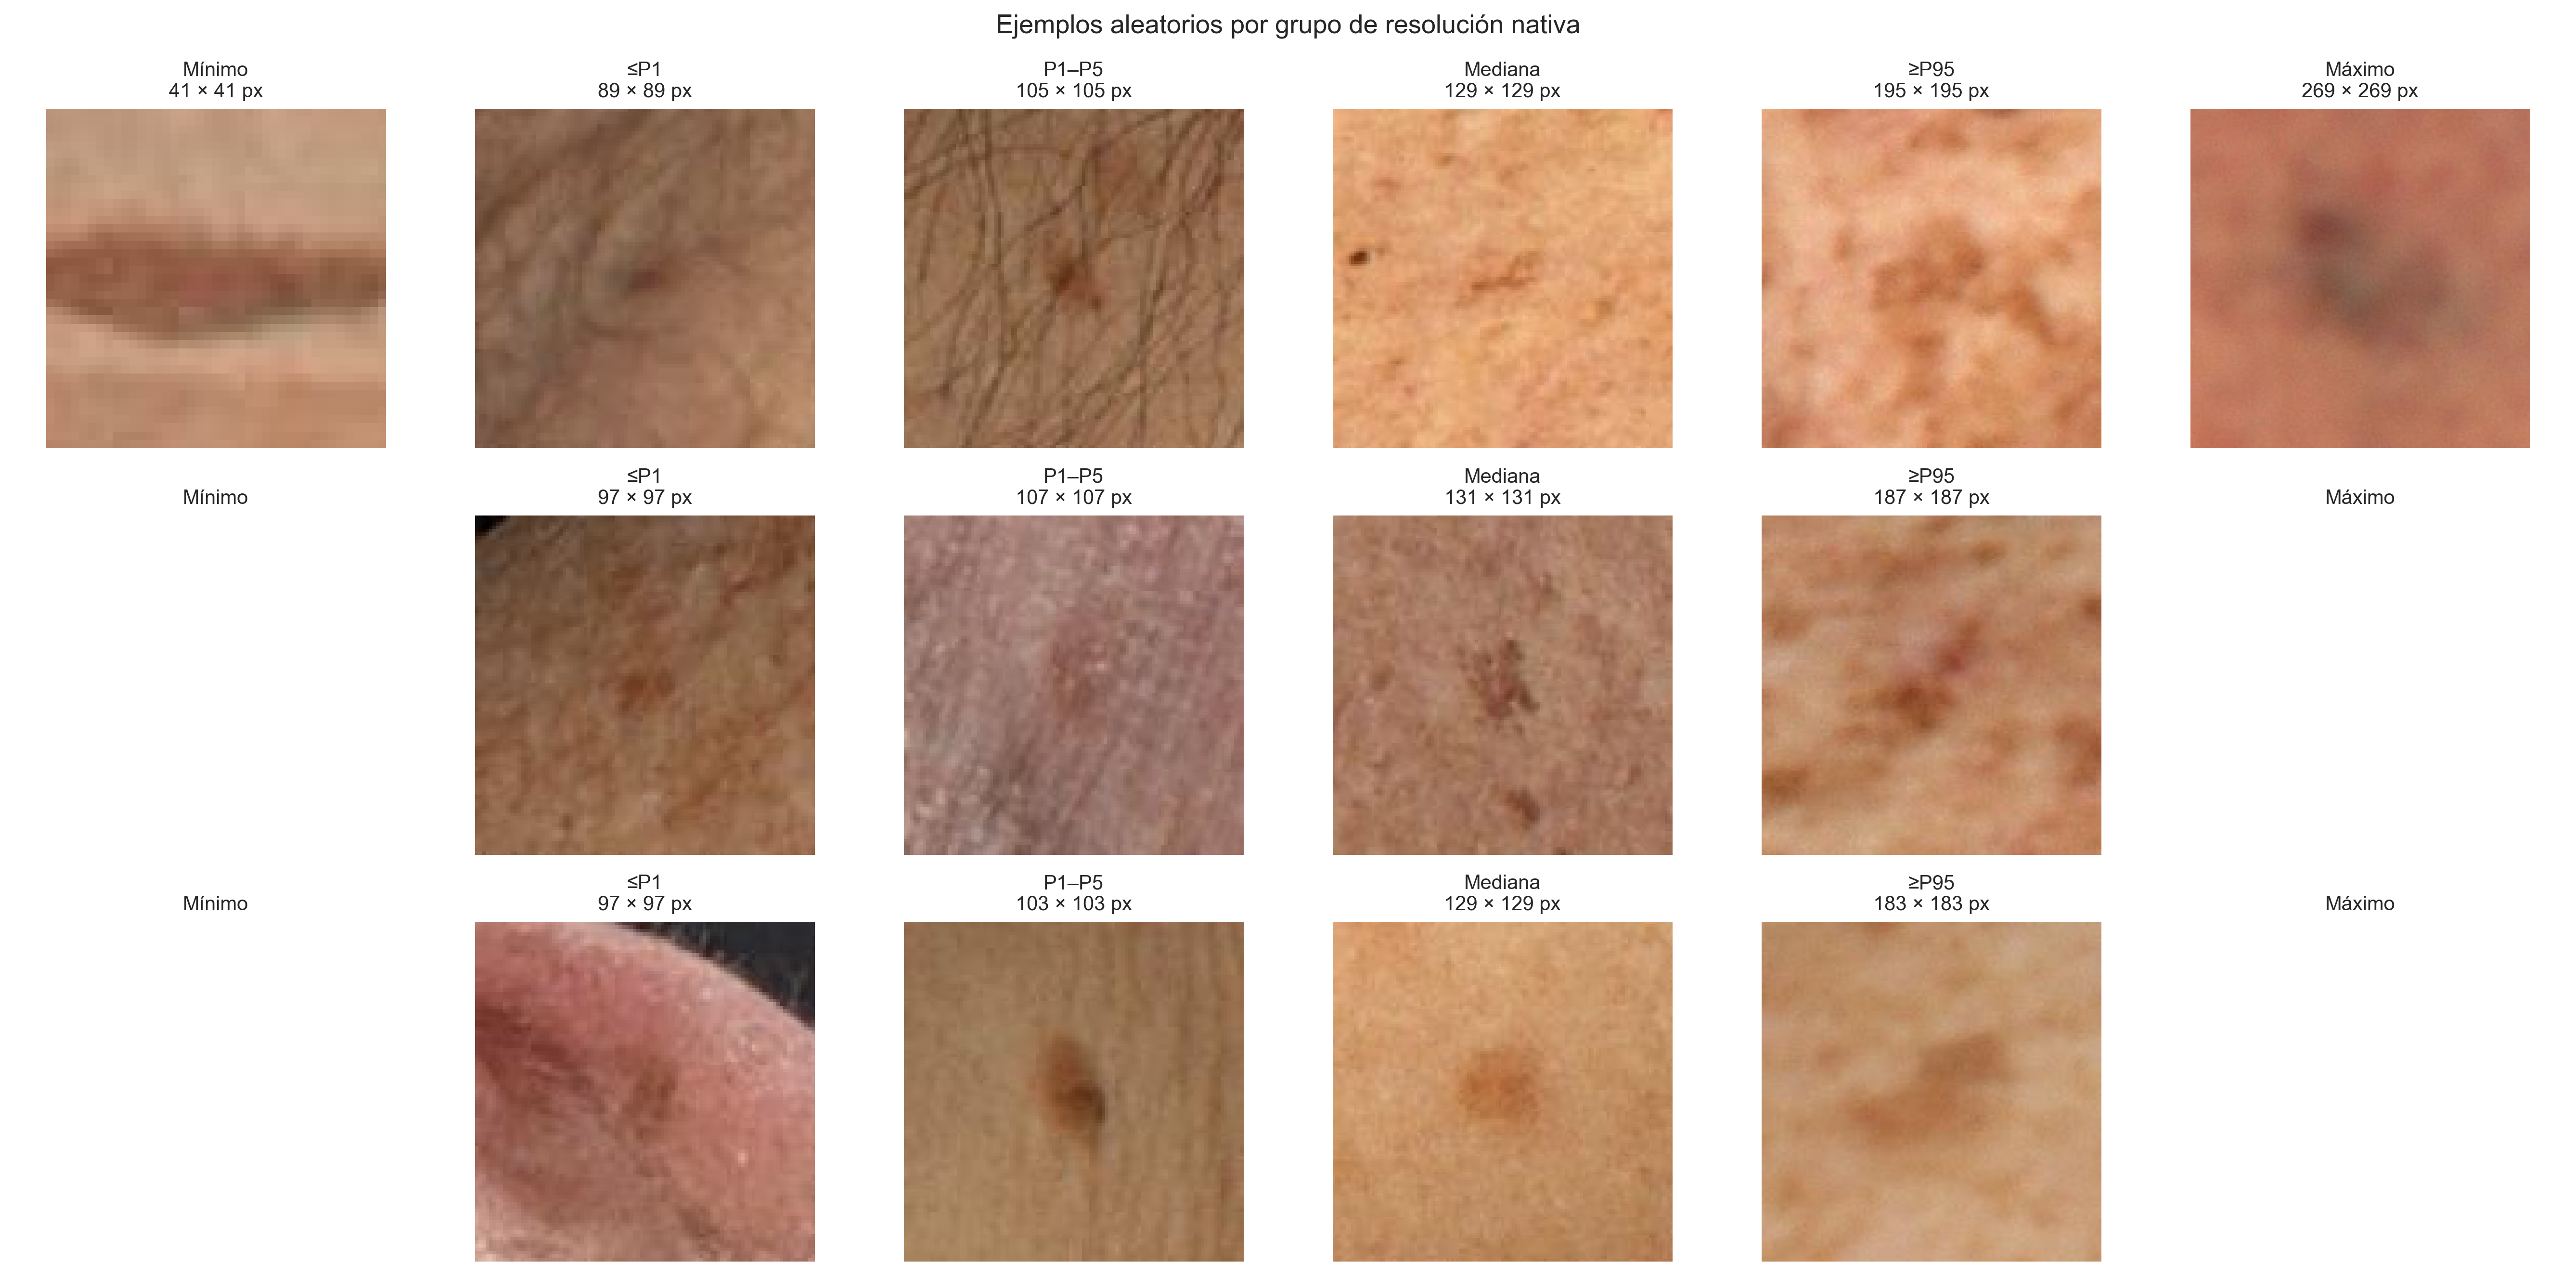

In [92]:
figures["native_image_examples_by_resolution"]

Figura XX. Ejemplos de imágenes nativas estratificadas por grupos de resolución. La inspección visual permite valorar si las imágenes de menor resolución conservan información suficiente o si presentan una degradación evidente.

## Evaluación de tamaños candidatos de entrada

Dado que los modelos de imagen requieren entradas de tamaño fijo, se evaluaron varios tamaños candidatos. Inicialmente se consideraron tamaños estándar como **96 × 96**, **128 × 128**, **160 × 160**, **192 × 192** y **224 × 224**. Posteriormente, al observar que la mediana nativa era de 131 px, se realizó un análisis más fino alrededor de esta zona, incorporando tamaños intermedios como **136 × 136** y **144 × 144**.

El análisis cuantitativo del redimensionamiento mostró que el punto de transición entre downsampling y upsampling se sitúa alrededor de la resolución central del dataset. A **128 × 128**, el comportamiento es relativamente equilibrado: el 40.09% de las imágenes requieren upsampling y el 59.91% downsampling. A **136 × 136**, el balance se desplaza ligeramente hacia el upsampling, con un 60.71% de imágenes ampliadas. A **144 × 144**, el porcentaje de imágenes con upsampling aumenta hasta el 76.53%, aunque la mayoría de ampliaciones siguen siendo leves.

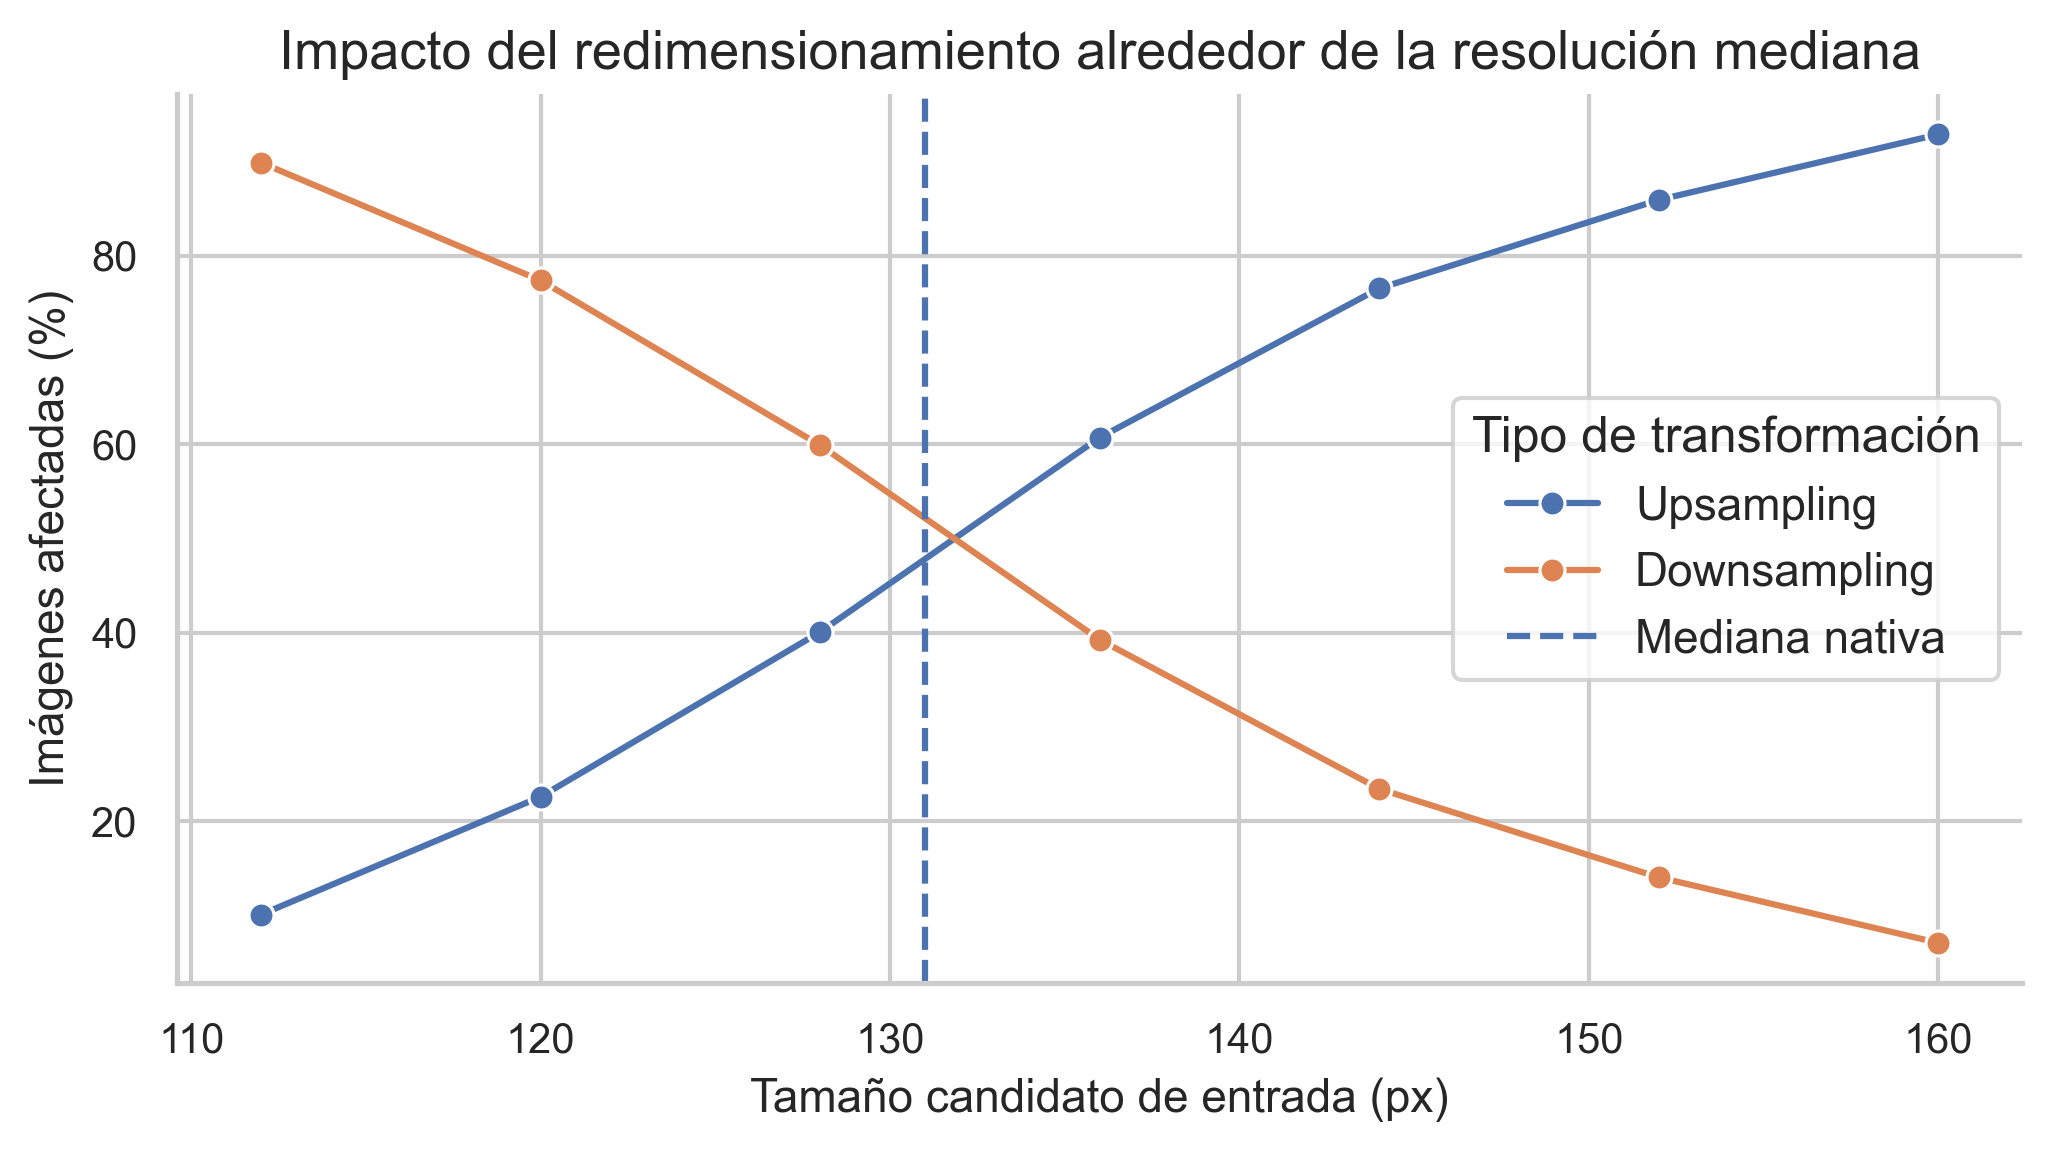

In [93]:
figures["fine_resize_impact"]

Figura XX. Impacto del redimensionamiento alrededor de la resolución mediana. El gráfico muestra cómo el porcentaje de imágenes sometidas a upsampling aumenta al superar la zona central de resolución nativa del dataset.

Además de cuantificar si una imagen se amplía o se reduce, se evaluó la severidad del upsampling. Esto es importante porque aumentar el tamaño de una imagen mediante interpolación no recupera información espacial que no estuviera presente en la imagen original. Se utilizaron dos umbrales: upsampling superior a **1.5×** y upsampling superior a **2×**.

| Tamaño candidato | Tipo                               | Cualquier upsampling (%) | >1.5× upsampling (%) | >2× upsampling (%) | Coste relativo vs 128 | Tamaño JPG estimado (GB) | Batch 64 `float32` (MB) |
| ---------------: | ---------------------------------- | -----------------------: | -------------------: | -----------------: | --------------------: | -----------------------: | ----------------------: |
|               96 | Referencia ligera                  |                     0.88 |                 0.02 |               0.00 |                 0.562 |                     1.13 |                    6.75 |
|              128 | Candidato conservador              |                    40.09 |                 0.27 |               0.02 |                 1.000 |                     1.73 |                   12.00 |
|              136 | Candidato principal                |                    60.71 |                 0.42 |               0.04 |                 1.129 |                     1.92 |                   13.55 |
|              144 | Candidato alta resolución moderada |                    76.53 |                 0.88 |               0.06 |                 1.266 |                     2.05 |                   15.19 |
|              160 | Referencia superior                |                    92.87 |                 4.32 |               0.14 |                 1.562 |                     2.39 |                   18.75 |
|              224 | Compatibilidad pretrained          |                    99.93 |                83.84 |              10.13 |                 3.062 |                     3.79 |                   36.75 |

Tabla XX. Comparación integrada de los tamaños candidatos según impacto de redimensionamiento, severidad del upsampling, coste computacional relativo y almacenamiento estimado.

Los resultados muestran que **128 × 128**, **136 × 136** y **144 × 144** son los tamaños más razonables para continuar el desarrollo del proyecto. Los tres presentan un número muy bajo de imágenes con upsampling extremo: 86 imágenes para 128 × 128, 148 para 136 × 136 y 243 para 144 × 144. Estas cifras representan menos del 0.1% del dataset en los tres casos.

En cambio, **160 × 160** ya implica upsampling para el 92.87% de las imágenes y un aumento más visible del coste computacional. Puede ser útil como referencia superior, pero no parece la opción más natural para este dataset. Por otro lado, **224 × 224** está claramente desalineado con la resolución nativa: más del 80% de las imágenes requerirían upsampling superior a 1.5× y un 10.13% requeriría upsampling superior a 2×. Por tanto, este tamaño solo debería considerarse si se utiliza una arquitectura preentrenada que lo requiera explícitamente.

## Inspección visual del redimensionamiento

La inspección visual confirma la interpretación cuantitativa. En imágenes de resolución muy baja, como el ejemplo mínimo de 41 × 41 px, redimensionar a tamaños mayores no recupera detalle real, sino que simplemente amplía la estructura existente mediante interpolación. En imágenes cercanas al percentil 1 o al percentil 5, las diferencias visuales entre 128 × 128, 136 × 136 y 144 × 144 son pequeñas. En imágenes cercanas a la mediana, estos tres tamaños implican transformaciones leves.

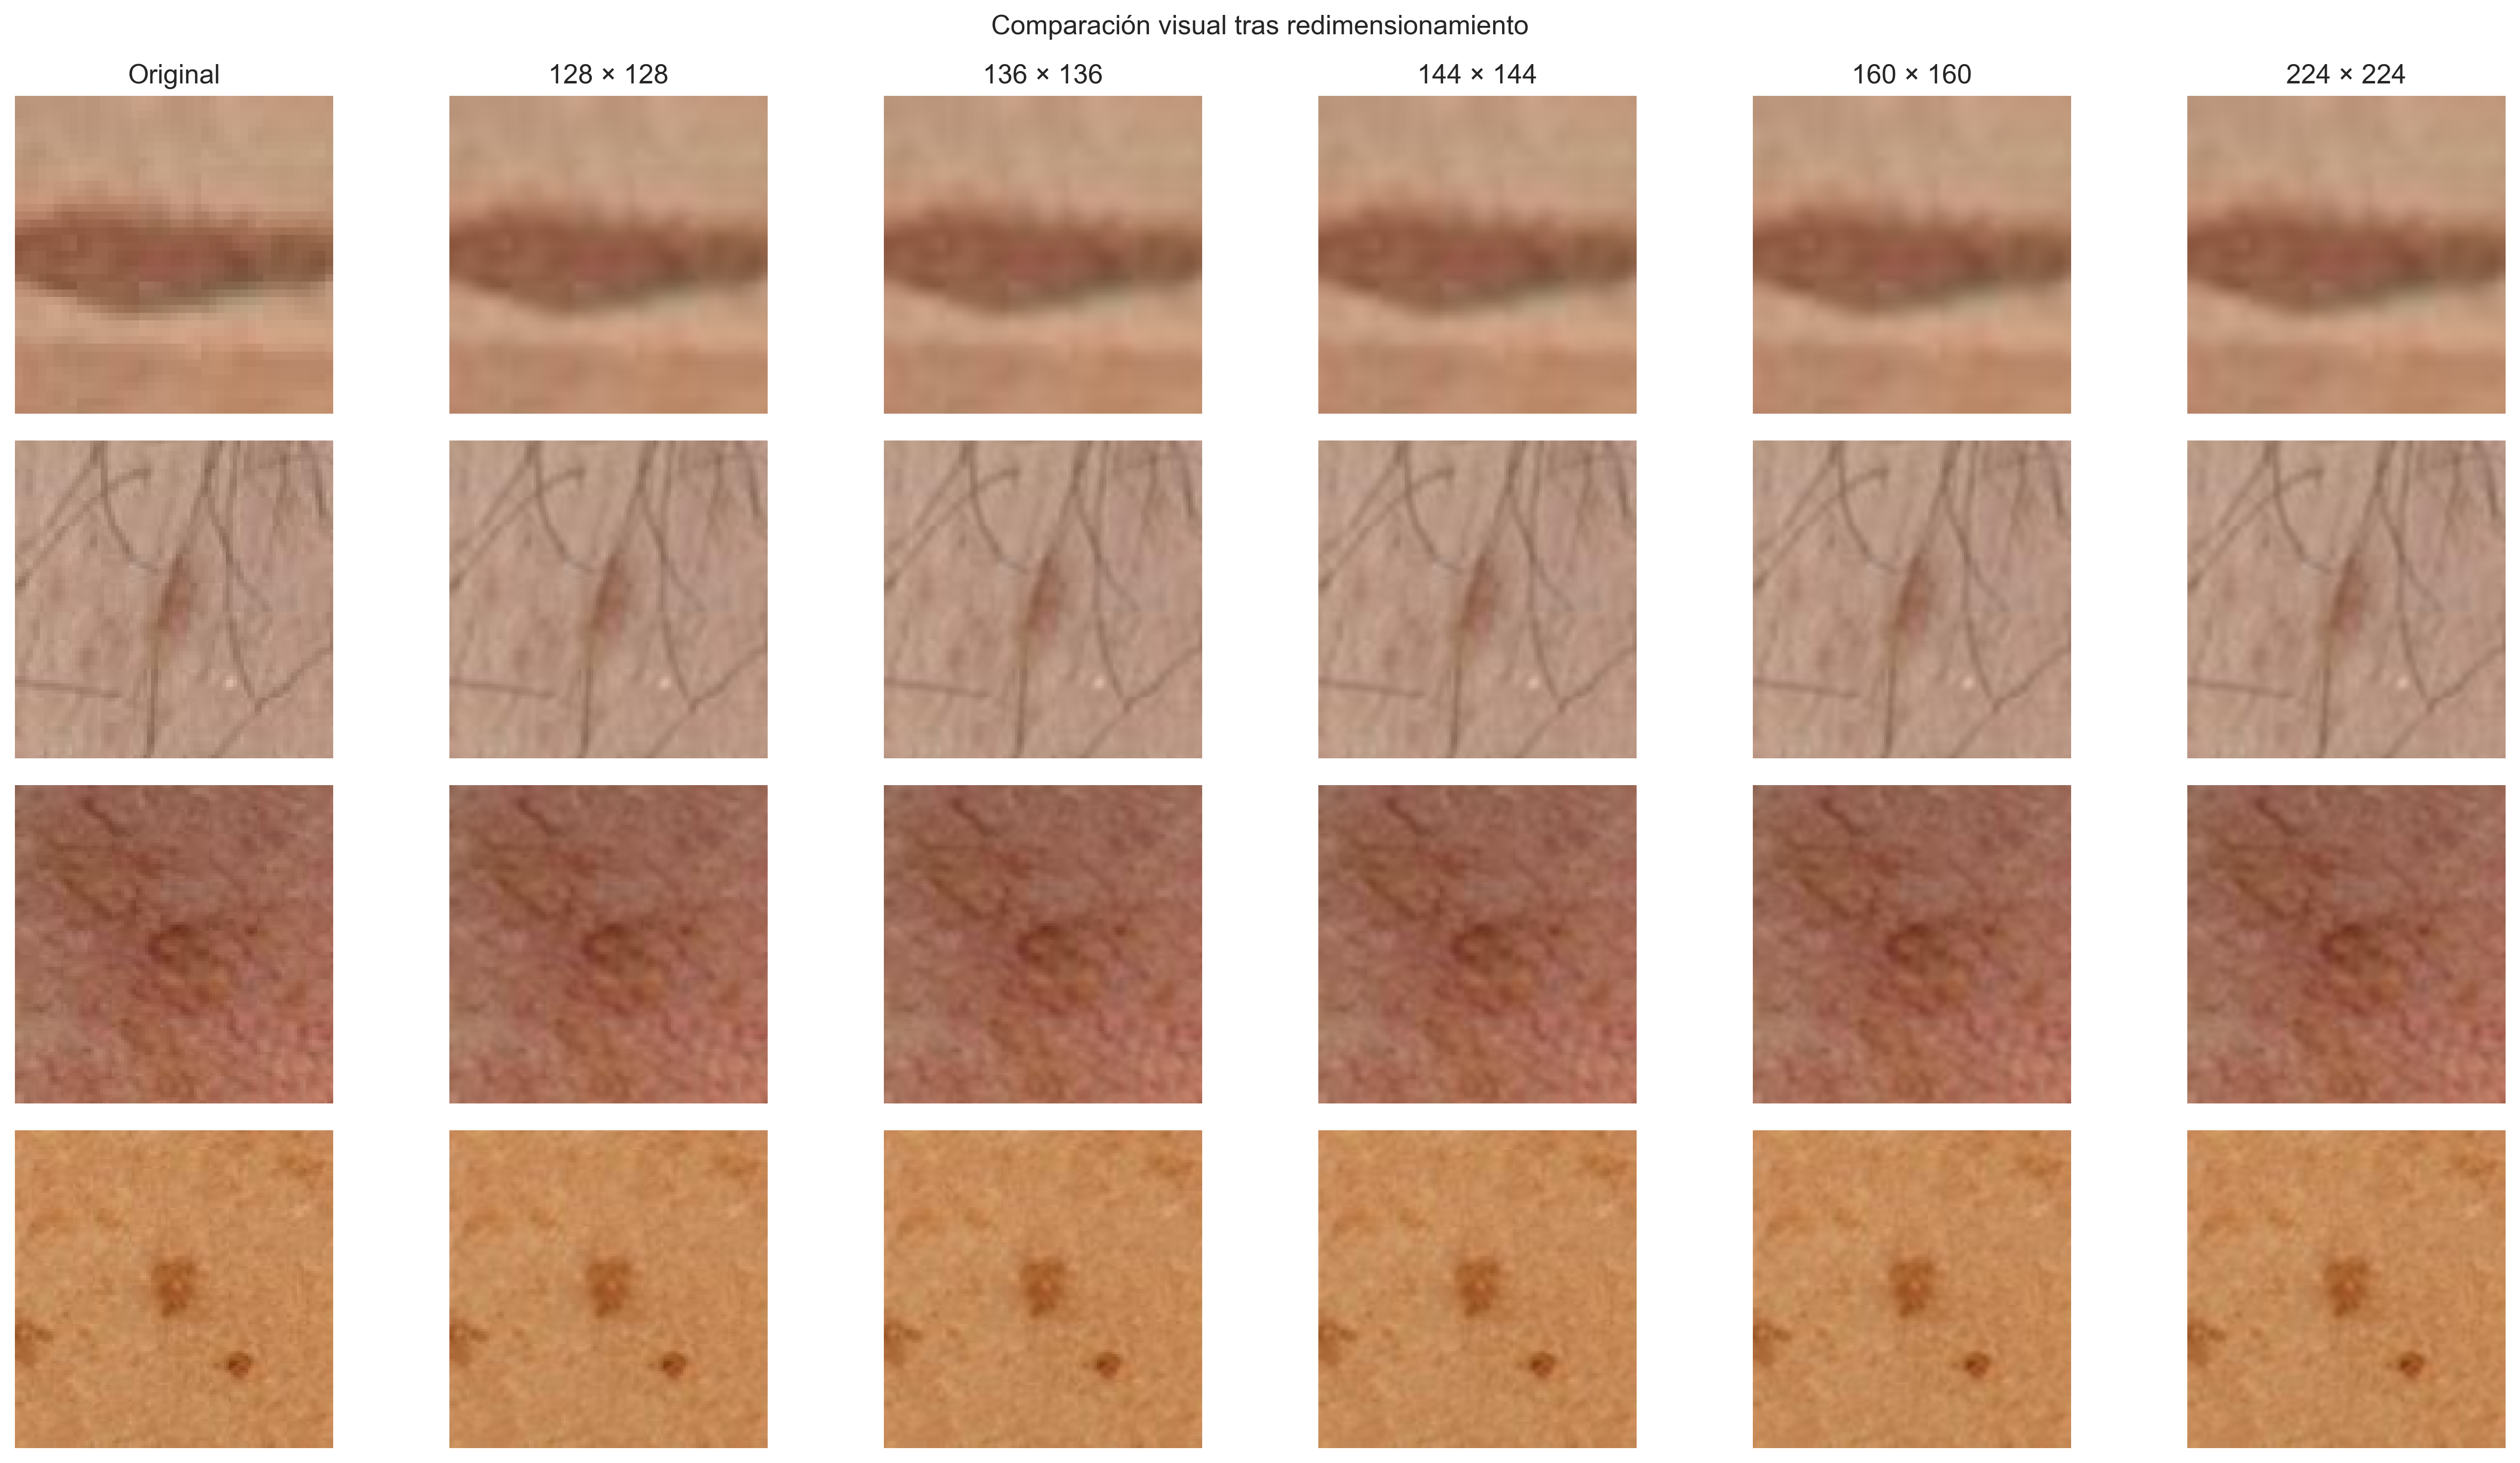

In [94]:
figures["resize_visual_comparison"]

Figura XX. Comparación visual de imágenes representativas tras redimensionamiento a distintos tamaños candidatos. Las ampliaciones progresivas no añaden información nueva en imágenes de baja resolución, aunque los tamaños 128 × 128, 136 × 136 y 144 × 144 mantienen una apariencia visual razonable.

Por tanto, no se recomienda excluir imágenes únicamente por su resolución nativa. Las imágenes con upsampling extremo deben conservarse inicialmente, pero conviene marcarlas mediante variables auxiliares para poder inspeccionarlas y, si fuera necesario, realizar análisis de sensibilidad posteriores.

## Coste de almacenamiento y coste computacional

El dataset original ocupa aproximadamente **1.06 GB** en disco en formato JPG comprimido. Los archivos individuales son pequeños, con una mediana de **2.72 KB** y un percentil 95 de **3.79 KB**.

| Métrica                   |   Valor |
| ------------------------- | ------: |
| Imágenes                  | 401,059 |
| Tamaño total JPG crudo    | 1.06 GB |
| Tamaño medio por imagen   | 2.77 KB |
| Tamaño mediano por imagen | 2.72 KB |
| Percentil 95              | 3.79 KB |
| Tamaño máximo             | 7.69 KB |

Tabla XX. Tamaño en disco del dataset original de imágenes JPG.

Sin embargo, el tamaño comprimido en disco no refleja directamente el coste durante el entrenamiento. Una vez cargadas, las imágenes se decodifican y se convierten en tensores. Por tanto, el coste computacional depende principalmente del tamaño de entrada, del número de canales, del tipo de dato y del tamaño de batch. Como el número de píxeles crece de forma cuadrática con el tamaño de entrada, pasar de 128 × 128 a 224 × 224 supone multiplicar el número de píxeles por aproximadamente 3.06.

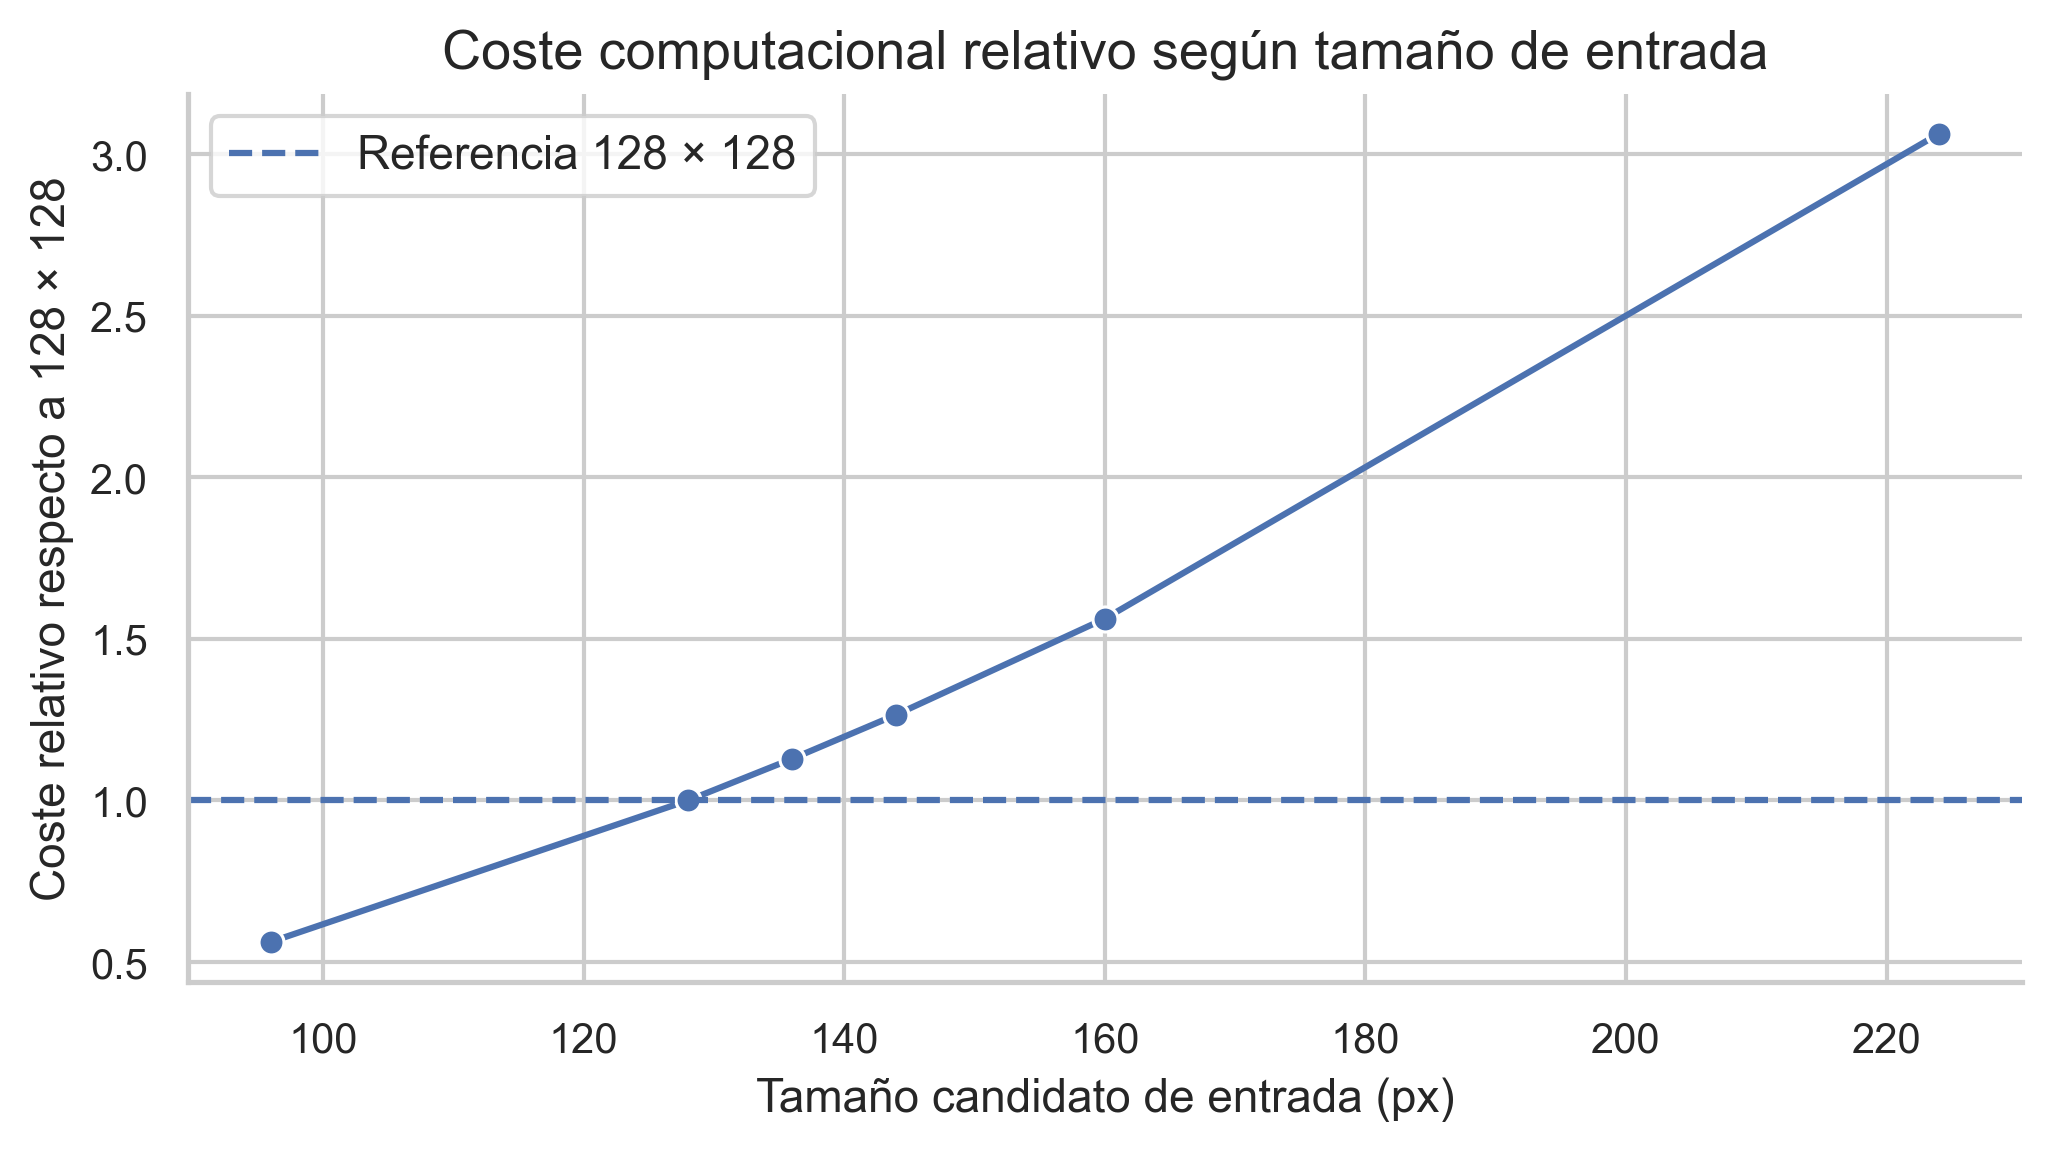

In [95]:
figures["relative_computational_cost"]

Figura XX. Coste computacional relativo de los tamaños candidatos usando 128 × 128 como referencia. El aumento de resolución produce un incremento cuadrático del número de píxeles.

Desde el punto de vista del almacenamiento, generar copias JPG redimensionadas sigue siendo factible para todos los tamaños analizados. Aun así, el incremento es relevante: 136 × 136 requeriría aproximadamente **1.92 GB**, 144 × 144 aproximadamente **2.05 GB** y 224 × 224 aproximadamente **3.79 GB**. El principal problema de los tamaños grandes no es solo el almacenamiento, sino el incremento de memoria, tiempo de entrenamiento y posible interpolación innecesaria.

## Selección final de tamaño de imagen

En conjunto, el análisis sugiere que el tamaño más razonable como opción principal es **136 × 136 px**. Este tamaño está cerca de la resolución mediana nativa, se sitúa cerca del punto de transición entre downsampling y upsampling, mantiene un coste computacional moderado y presenta una proporción mínima de upsampling extremo.

| Escenario                                             | Tamaño recomendado | Justificación                                                                |
| ----------------------------------------------------- | -----------------: | ---------------------------------------------------------------------------- |
| Opción principal / óptima                             |          136 × 136 | Mejor equilibrio entre detalle espacial, interpolación y coste computacional |
| Opción conservadora o con limitaciones moderadas      |          128 × 128 | Menor coste, muy próxima a la mediana nativa y con menos upsampling          |
| Opción si se dispone de buena capacidad computacional |          144 × 144 | Mayor resolución con coste aún asumible y upsampling extremo muy bajo        |
| Opción de bajo coste extremo                          |            96 × 96 | Muy eficiente, pero con riesgo de perder detalle espacial                    |
| Referencia superior experimental                      |          160 × 160 | Factible, pero menos alineada con la resolución nativa                       |
| Solo si lo exige una arquitectura preentrenada        |          224 × 224 | Coste alto y upsampling severo en una proporción relevante de imágenes       |

Tabla XX. Recomendación final de tamaños candidatos según escenario computacional.

La recomendación práctica es utilizar **136 × 136** como tamaño principal para generar el dataset transformado. Si se busca una opción más conservadora, especialmente en fases iniciales de prototipado o si existen restricciones de memoria, **128 × 128** es una alternativa segura. Si se dispone de mayor capacidad computacional y se quiere evaluar si una resolución ligeramente superior mejora el rendimiento, **144 × 144** es la opción más razonable. El tamaño **224 × 224** no debería utilizarse como elección por defecto, salvo que sea necesario por compatibilidad con modelos preentrenados específicos.

## Recomendaciones para generar el Parquet de imágenes transformadas

Para la generación del dataset transformado, se recomienda crear una versión principal con imágenes redimensionadas a **136 × 136 × 3**. Esta versión debería almacenar las imágenes en formato `uint8` siempre que sea posible, manteniendo los valores de píxel en el rango `0–255`. La normalización debería aplicarse posteriormente dentro del pipeline de entrenamiento, no necesariamente en el archivo Parquet final. Esta estrategia reduce el tamaño en disco y evita guardar una versión `float32` más pesada.

El Parquet debería incluir, como mínimo, las siguientes columnas:

| Tipo de información              | Columnas recomendadas                                                      |
| -------------------------------- | -------------------------------------------------------------------------- |
| Identificación                   | `image_id`, `patient_id` si está disponible                                |
| Variables objetivo               | Variables de biopsia, malignidad o grupo diagnóstico usadas en el modelado |
| Metadatos clínicos preprocesados | `sex`, `age_approx`, `anatom_site_general`, `clin_size_long_diam_mm`       |
| Información de imagen original   | `original_width`, `original_height`, `original_aspect_ratio`               |
| Información de transformación    | `target_size`, `scale_factor`, `was_upsampled`, `was_downsampled`          |
| Flags de calidad                 | `upsampling_gt_1_5x`, `upsampling_gt_2x`, `low_resolution_flag`            |
| Imagen transformada              | Array/tensor `136 × 136 × 3` o representación binaria equivalente          |

Tabla XX. Estructura recomendada para el Parquet de imágenes transformadas.

Se recomienda evitar eliminar imágenes en esta fase únicamente por baja resolución. En su lugar, las imágenes de resolución extrema o con upsampling superior a 2× deberían quedar identificadas mediante flags. Esto permitirá evaluar posteriormente si estos casos afectan al rendimiento del modelo, si se concentran en determinados centros o grupos diagnósticos, o si conviene excluirlos en análisis de sensibilidad.

Durante el entrenamiento, el pipeline debería convertir las imágenes a `float32` y normalizar los valores. Para modelos entrenados desde cero, una normalización simple dividiendo entre 255 puede ser suficiente como punto de partida. Si se emplean arquitecturas preentrenadas, deberá aplicarse la normalización esperada por la arquitectura correspondiente, aunque en ese caso debe tenerse en cuenta que tamaños como 224 × 224 no están bien alineados con la resolución nativa del dataset.

En resumen, el análisis apoya la siguiente estrategia:

1. Generar el dataset principal redimensionado a **136 × 136 × 3**.
2. Conservar las imágenes en `uint8` en el archivo transformado y normalizarlas durante el entrenamiento.
3. Incluir variables auxiliares sobre resolución nativa y severidad del redimensionamiento.
4. No excluir imágenes automáticamente por resolución.
5. Usar **128 × 128** como alternativa conservadora si aparecen limitaciones computacionales.
6. Evaluar **144 × 144** como alternativa de mayor resolución si el hardware lo permite.
7. Reservar **224 × 224** solo para escenarios específicos de compatibilidad con modelos preentrenados.

Esta decisión permite trabajar con un dataset homogéneo, técnicamente consistente y computacionalmente manejable, minimizando tanto la pérdida de detalle por downsampling como la introducción innecesaria de interpolación por upsampling.
